In [7]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
big_plt_font()

In [4]:
data_dir = '/home/electron/data/experiment_06232026'

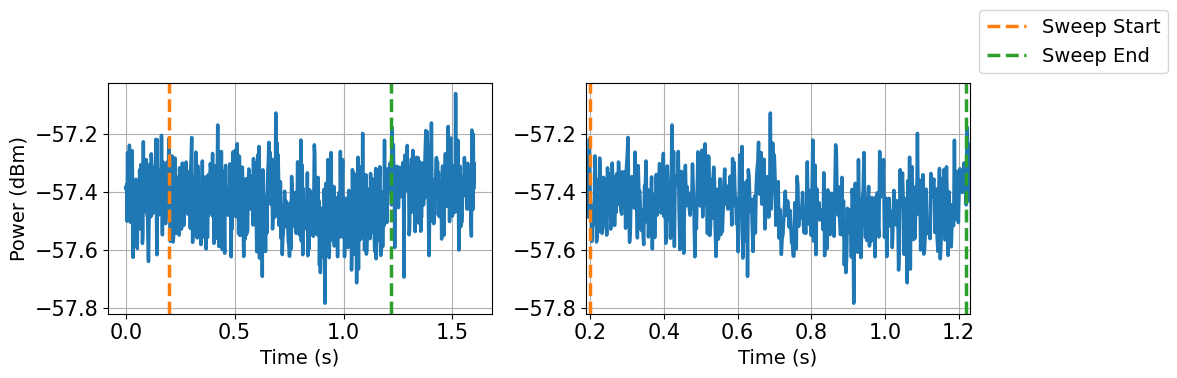

In [5]:
file = load_latest_data() 
data = file['all_meas'] 
t_start = file['t_sweep_start'] - file['t_tip_settle']
t_sweep_start = file['hold_time']
t_sweep_end = file['t_sweep_end'] - t_start - file['hold_time']
t_tip_off = file['t_tip_off'] - t_start - file['hold_time']
t_seq_end = file['SSA_SWT']
data_avg = np.mean(data, axis=0) 
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
t_axis = np.linspace(0, t_seq_end, len(data_avg)) 
T_zoom_expansion = max(2*(t_tip_off[-1] - t_sweep_end[-1]), 0.01)
plot_ax(ax[0], t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')
plot_ax(ax[1], t_axis, data_avg, xlabel='Time (s)')
ax[0].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[0].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
# ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[1].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
# ax[1].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].set_xlim((t_sweep_start-T_zoom_expansion, t_sweep_end[-1]+T_zoom_expansion))
ax[1].legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [123]:
file['t_sweep_end'] - file['t_sweep_start']

array([-1.58102083, -1.58143997, -1.58125782, -1.58061004, -1.58050537,
       -1.58051395, -1.58059001, -1.58038235, -1.58052301, -1.58077335,
       -1.58089018, -1.58030534, -1.58055949, -1.58083367, -1.58071208,
       -1.58060551, -1.58055162, -1.58053899, -1.58046699, -1.58056474,
       -1.58051467, -1.58187747, -1.58173537, -1.58037853, -1.58089042,
       -1.58051562, -1.58049917, -1.58112788, -1.58190441, -1.5809145 ,
       -1.58062911, -1.5813005 , -1.58030963, -1.58034444, -1.58059216,
       -1.58083415, -1.58060741, -1.58100176, -1.58056784, -1.58054757,
       -1.58046269, -1.58033872, -1.58144188, -1.58043313, -1.58066297,
       -1.58074975, -1.58044386, -1.58038425, -1.5803318 , -1.58147693,
       -1.58061934, -1.58069587, -1.58140492, -1.58056927, -1.58027816,
       -1.58043146, -1.58028769, -1.58102036, -1.58062243, -1.58062482,
       -1.58052373, -1.58109808, -1.5805254 , -1.58064151])

In [25]:
file['filename']

'/home/electron/data/experiment_06232026/RFPowerSweepAWG_10-24-48.h5'

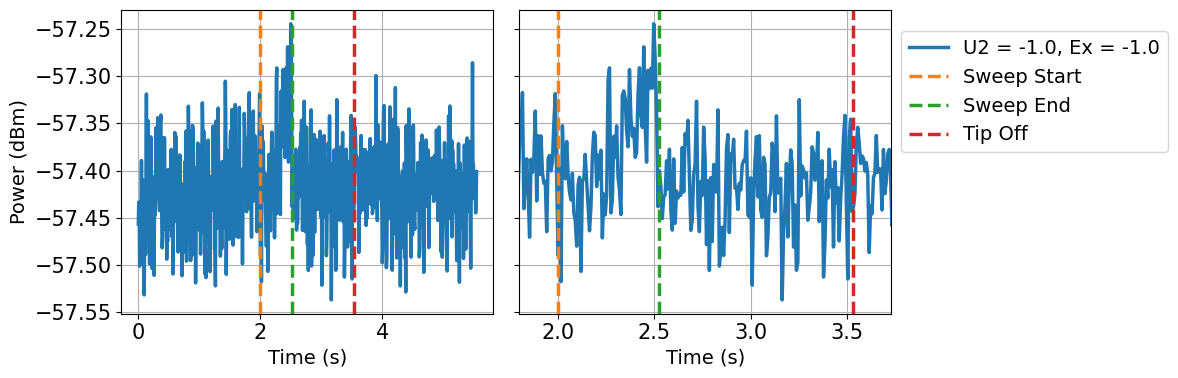

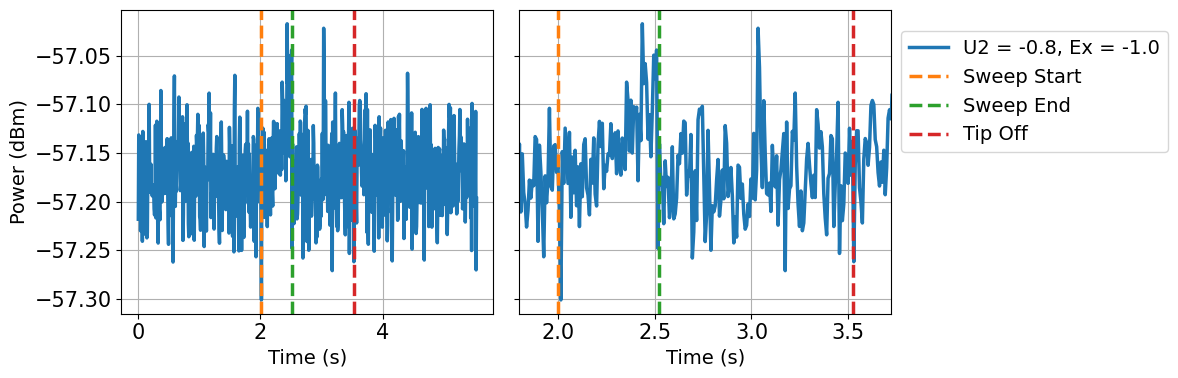

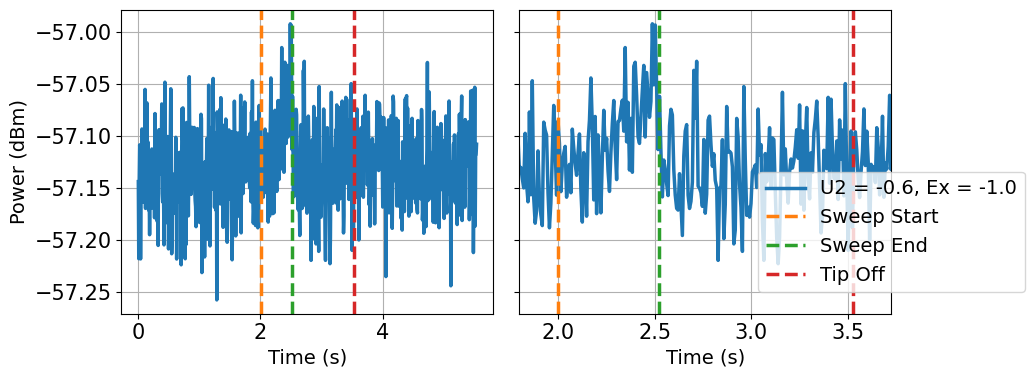

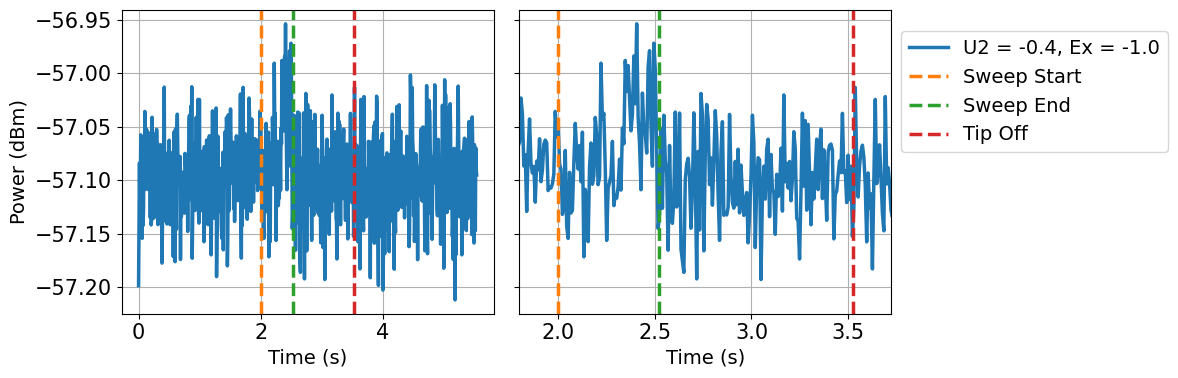

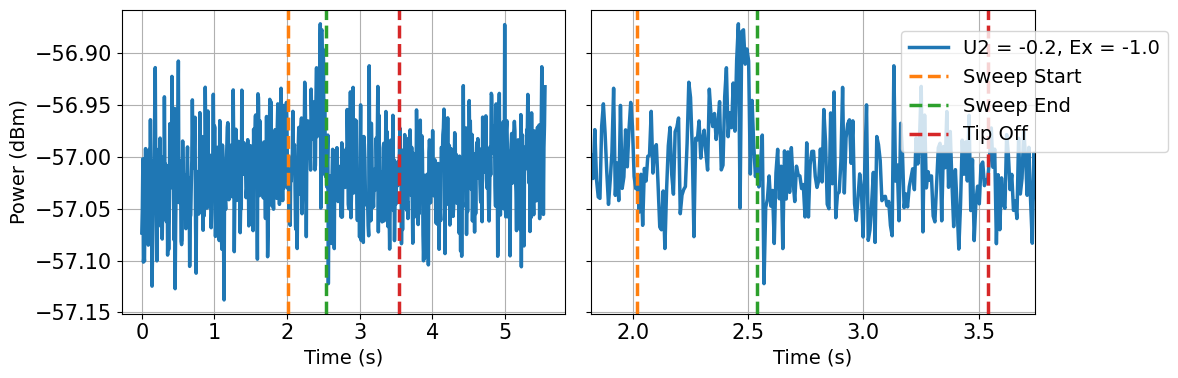

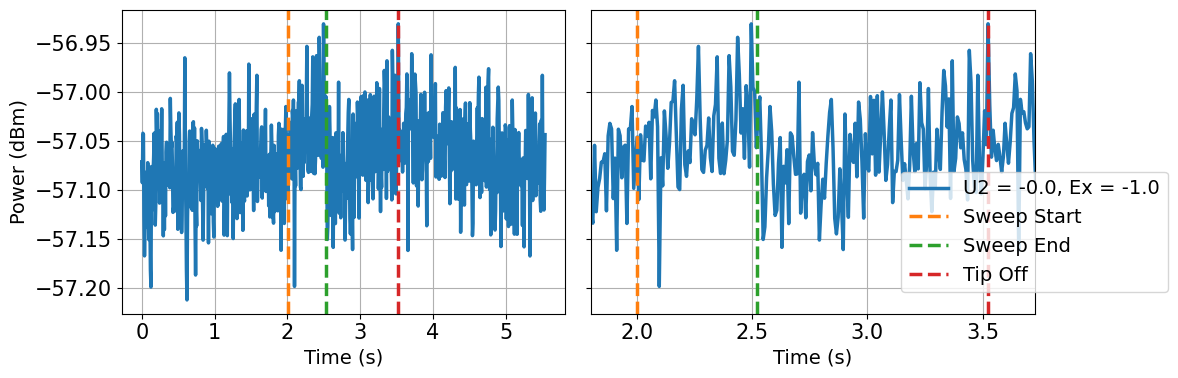

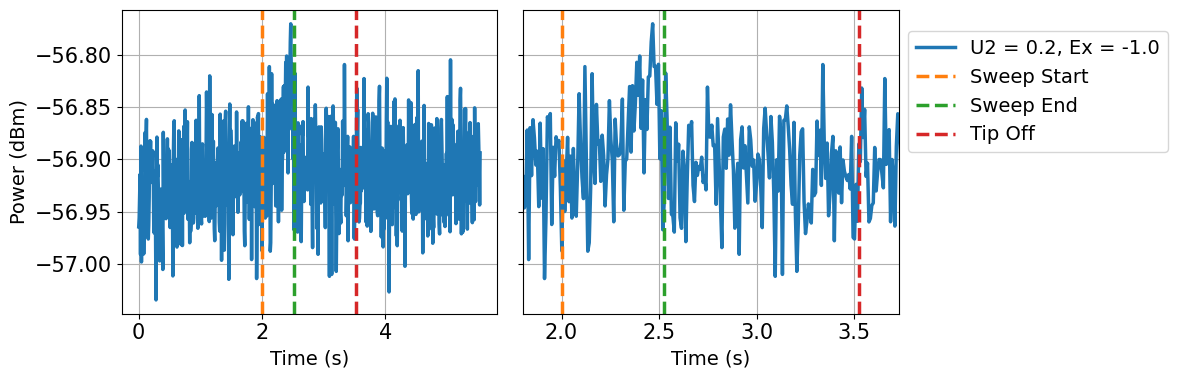

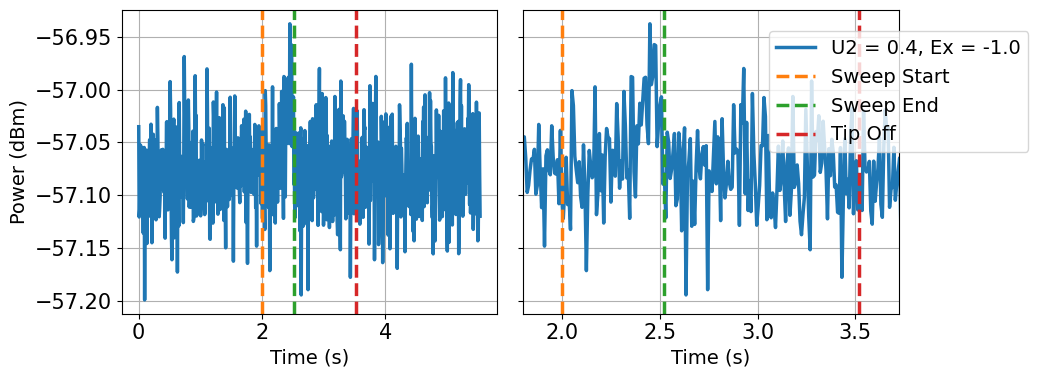

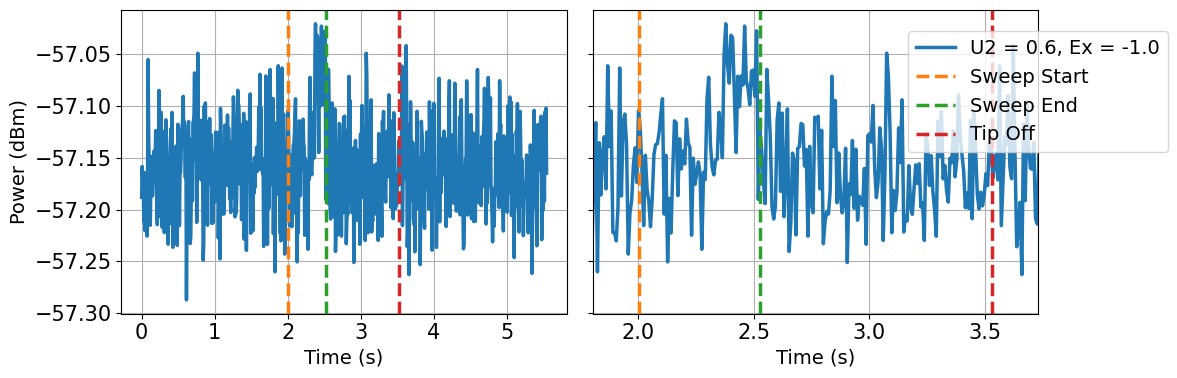

In [65]:
files = ['data/experiment_06232026/RFPowerSweepAWG_12-08-50.h5', 
         'data/experiment_06232026/RFPowerSweepAWG_12-20-25.h5', 
         'data/experiment_06232026/RFPowerSweepAWG_12-32-00.h5', 
         'data/experiment_06232026/RFPowerSweepAWG_12-43-34.h5',
         'data/experiment_06232026/RFPowerSweepAWG_12-55-09.h5', 
        'data/experiment_06232026/RFPowerSweepAWG_13-06-43.h5', 
        'data/experiment_06232026/RFPowerSweepAWG_13-18-18.h5', 
        'data/experiment_06232026/RFPowerSweepAWG_13-29-53.h5', 
        'data/experiment_06232026/RFPowerSweepAWG_13-41-27.h5']
# labels = ['0.1s', '0.01s', '1s', '2s']

for i in range(len(files)): 
    fig, ax = plt.subplots(ncols=2, figsize=(12,4), sharey=True)
    filename = files[i] 
    file = load_h5_data(filename, base='/home/electron/') 
    data = file['all_meas'] 
    t_start = file['t_tip_on']
    t_sweep_start = file['t_sweep_start'] - t_start
    t_sweep_end = file['t_sweep_end']-1 - t_start 
    t_tip_off = file['t_tip_off'] - t_start
    t_seq_end = file['t_seq_end'] - t_start 
    data_avg = np.mean(data, axis=0) 
    t_axis = np.linspace(0, t_seq_end[-1], len(data_avg)) 
    T_zoom_expansion = min(max(2*(t_tip_off[-1] - t_sweep_end[-1]), 0.01), 0.2)
    plot_ax(ax[0], t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')
    plot_ax(ax[1], t_axis, data_avg, xlabel='Time (s)', label=f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}")
    # if i > 0:
    #     ax[1].set_xlim((min(ax[1].get_xlim()[0], t_sweep_start[-1]-T_zoom_expansion), max(t_tip_off[-1]+T_zoom_expansion, ax[1].get_xlim()[1])))
    # else:
    ax[0].axvline(t_sweep_start[-1], linestyle='--', c='C1', label='Sweep Start')
    ax[0].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
    ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
    ax[1].axvline(t_sweep_start[-1], linestyle='--', c='C1', label='Sweep Start')
    ax[1].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
    ax[1].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
    ax[1].set_xlim((t_sweep_start[-1]-T_zoom_expansion, t_tip_off[-1]+T_zoom_expansion))
    ax[1].legend(bbox_to_anchor=(1,0.5))
    plt.tight_layout()
    plt.show()

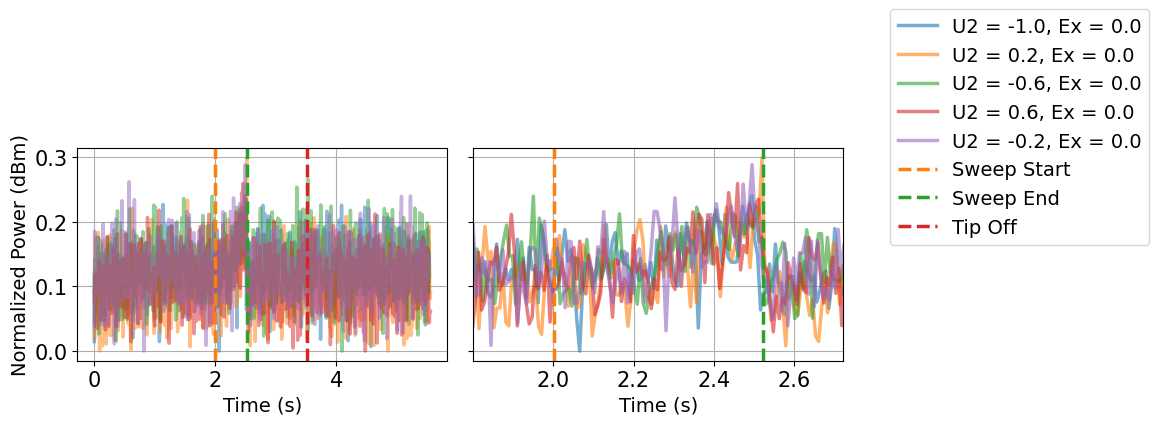

In [98]:
all_data_files = list_filenames(data_dir)
files = [i for i in all_data_files if 'RFPowerSweepAWG' in i and i[-11:-3] > '14-36-00']
# labels = ['0.1s', '0.01s', '1s', '2s']

fig, ax = plt.subplots(ncols=2, figsize=(12,4), sharey=True)
for i in range(len(files)): 
    
    filename = files[i] 
    file = load_h5_data(filename, base='/home/electron/data/experiment_06232026') 
    if file['Ex'] != 0: 
        continue
    data = file['all_meas'] 
    t_start = file['t_tip_on']
    t_sweep_start = file['t_sweep_start'] - t_start
    t_sweep_end = file['t_sweep_end']-1 - t_start 
    t_tip_off = file['t_tip_off'] - t_start
    t_seq_end = file['t_seq_end'] - t_start 
    data_avg = np.mean(data, axis=0) 
    t_axis = np.linspace(0, t_seq_end[-1], len(data_avg)) 
    T_zoom_expansion = min(max(2*(t_tip_off[-1] - t_sweep_end[-1]), 0.01), 0.2)
    plot_ax(ax[0], t_axis, data_avg-min(data_avg), xlabel='Time (s)', ylabel='Normalized Power (dBm)', alpha=0.5)
    plot_ax(ax[1], t_axis, data_avg-min(data_avg), xlabel='Time (s)', label=f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}", alpha=0.6)
    # if i > 0:
    #     ax[1].set_xlim((min(ax[1].get_xlim()[0], t_sweep_start[-1]-T_zoom_expansion), max(t_tip_off[-1]+T_zoom_expansion, ax[1].get_xlim()[1])))
    # else:
ax[0].axvline(t_sweep_start[-1], linestyle='--', c='C1', label='Sweep Start')
ax[0].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].axvline(t_sweep_start[-1], linestyle='--', c='C1', label='Sweep Start')
ax[1].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
ax[1].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].set_xlim((t_sweep_start[-1]-T_zoom_expansion, t_sweep_end[-1]+T_zoom_expansion))
ax[1].legend(bbox_to_anchor=(1.1,0.5))
plt.tight_layout()
plt.show()

In [252]:
from edes.utils.file_handling import list_filenames 
len([i for i in list_filenames('/home/electron/data/experiment_06232026') if 'RFPowerSweepAWGTipSwitched' in i and
                         i[-11:-3] != '22-13-49'])

57

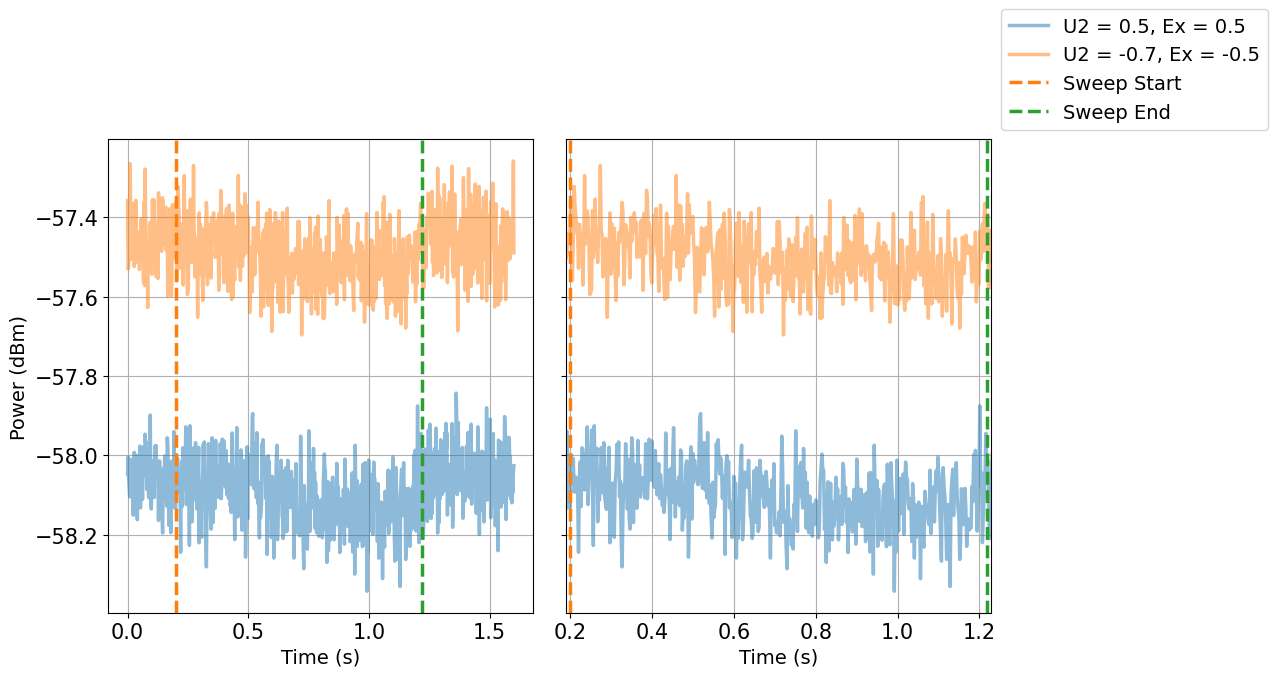

In [74]:
all_data_files = list_filenames(data_dir)
files = [i for i in all_data_files if 'RFPowerSweepAWGTipSwitched' in i and i[-11:-3] != '22-13-49']
# labels = ['0.1s', '0.01s', '1s', '2s']
fig, ax = plt.subplots(ncols=2, figsize=(13,7), sharey=True)
for i in range(len(files)): 
    # fig, ax = plt.subplots(ncols=2, figsize=(12,5), sharey=True)
    
    filename = files[i] 
    file = load_h5_data(filename, base=data_dir) 
    if file['U2'] == -0.7 and file['Ex'] == -0.5 and file['t_tip_settle'] == 3: 
        pass
    elif round(file['U2'],1) == 0.5 and file['Ex'] == 0.5 and file['t_tip_settle'] == 3: 
        pass
    else: 
        continue
    data = file['all_meas'] 
    t_start = file['t_sweep_start'] - file['t_tip_settle']
    t_sweep_start = file['hold_time']
    t_sweep_end = file['t_sweep_end'] - t_start - file['hold_time']
    t_tip_off = file['t_tip_off'] - t_start - file['hold_time']
    t_seq_end = file['SSA_SWT']
    data_avg = np.mean(data, axis=0) 
    t_axis = np.linspace(0, t_seq_end, len(data_avg)) 
    T_zoom_expansion = min(max(2*(t_tip_off[-1] - t_sweep_end[-1]), 0.01), 0.2)
    plot_ax(ax[0], t_axis, data_avg, alpha=0.5, xlabel='Time (s)', ylabel='Power (dBm)')
    plot_ax(ax[1], t_axis, data_avg, alpha=0.5, xlabel='Time (s)', label=f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}")
    # if i > 0:
    #     ax[1].set_xlim((min(ax[1].get_xlim()[0], t_sweep_start[-1]-T_zoom_expansion), max(t_tip_off[-1]+T_zoom_expansion, ax[1].get_xlim()[1])))
    # else:
ax[0].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[0].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
# ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[1].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
ax[1].set_xlim((t_sweep_start-T_zoom_expansion, t_sweep_end[-1]+T_zoom_expansion))
# plt.title(f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}, load time = {file['t_tip_settle']}s")
ax[1].legend(bbox_to_anchor=(1,1))
# ax[0].set_yscale('log')
plt.tight_layout()
plt.show()

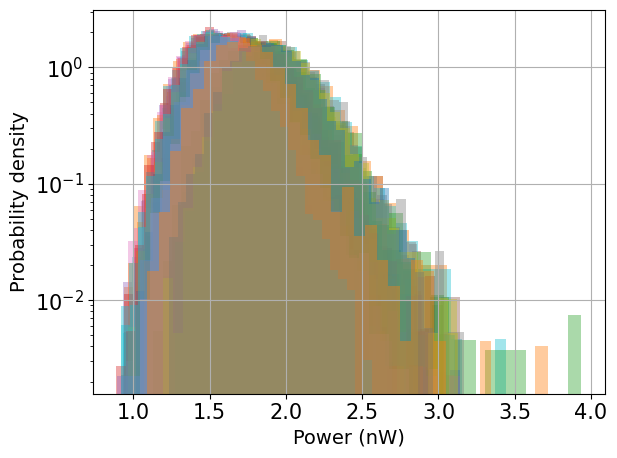

In [75]:
all_data_files = list_filenames(data_dir)
files = [i for i in all_data_files if 'RFPowerSweepAWGTipSwitched' in i and i[-11:-3] != '22-13-49']
# labels = ['0.1s', '0.01s', '1s', '2s']
all_data_ROI = []
all_Ex, all_U2, all_T_load = [] , [], []

big_plt_font()
for i in range(len(files)): 
    # fig, ax = plt.subplots(ncols=2, figsize=(12,5), sharey=True)
    filename = files[i] 
    file = load_h5_data(filename, base=data_dir) 
    data = file['all_meas'] 
    t_start = file['t_sweep_start'] - file['t_tip_settle']
    t_sweep_start = file['hold_time']
    t_sweep_end = file['t_sweep_end'] - t_start - file['hold_time']*2
    t_tip_off = file['t_tip_off'] - t_start - file['hold_time']
    t_seq_end = file['SSA_SWT']
    data_avg = np.concatenate(data, axis=0) 
    t_axis = np.linspace(0, t_seq_end, len(data_avg)) 
    T_zoom_expansion = min(max(2*(t_tip_off[-1] - t_sweep_end[-1]), 0.01), 0.2)
    
    # plot_ax(ax[0], t_axis, data_avg-min(data_avg), alpha=0.5, xlabel='Time (s)', ylabel='Power (dBm)')
    # plot_ax(ax[1], t_axis, dBm_to_W(data_avg, alpha=0.5, xlabel='Time (s)')#, label=f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}")
    # if i > 0:
    #     ax[1].set_xlim((min(ax[1].get_xlim()[0], t_sweep_start[-1]-T_zoom_expansion), max(t_tip_off[-1]+T_zoom_expansion, ax[1].get_xlim()[1])))
    # else:
    # ax[0].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
    # ax[0].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
    # # ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
    # ax[1].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
    # ax[1].axvline(t_sweep_end[-1], linestyle='--', c='C2', label='Sweep End') 
    # ax[1].set_xlim((t_sweep_start-T_zoom_expansion, t_sweep_end[-1]+T_zoom_expansion))
    # plt.title(f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}, load time = {file['t_tip_settle']}s")
    # ax[1].legend(False)
    # data_sel = data_avg[np.where((t_axis > t_sweep_start) & (t_axis < t_sweep_end[-1]))]
    data_sel = data_avg[np.where((t_axis < t_sweep_start))]
    # if file['Ex'] != -0.5 and file['t_tip_settle'] != 3:
    #     continue
    plt.hist((dBm_to_W(data_sel))*1e9, histtype='bar', alpha=0.4,
             lw=2, bins=30, density=True, label=f"U2 = {file['U2']:.1f}, Ex = {file['Ex']:.1f}, load time = {file['t_tip_settle']}s")
    all_data_ROI.append(data_sel) 
    all_Ex.append(file['Ex']) 
    all_U2.append(file['U2']) 
    all_T_load.append(file['t_tip_settle'])
plt.xlabel('Power (nW)')
plt.ylabel('Probability density')
plt.grid()
plt.yscale('log')
# plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

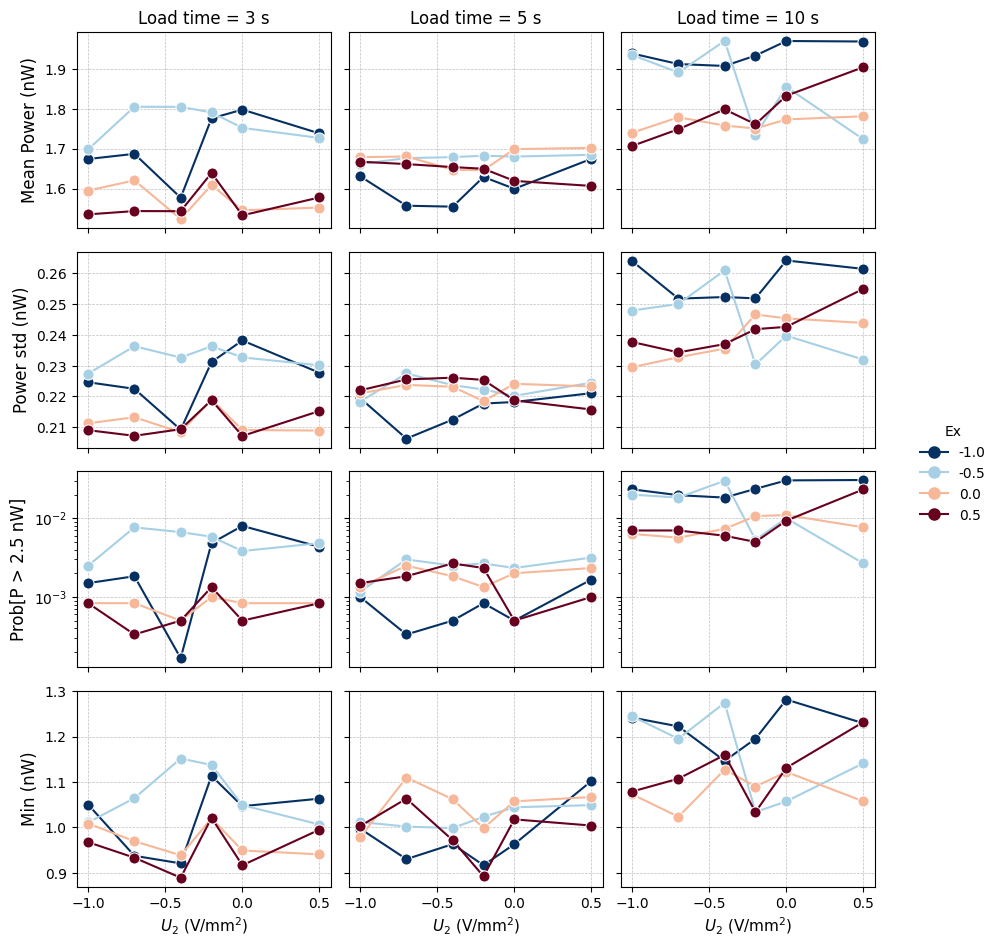

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CRITICAL: Reset to native Matplotlib style ---
sns.reset_orig()
plt.style.use('default') 

# --- 1. Compute metrics for each trial ---
means = np.array([np.mean(dBm_to_W(trial)*1e9) for trial in all_data_ROI])
stds = np.array([np.std(dBm_to_W(trial)*1e9) for trial in all_data_ROI])
maxs = np.array([len(trial[np.where((dBm_to_W(trial)*1e9 > 2.5))])/len(trial) for trial in all_data_ROI])
mins = np.array([np.min(dBm_to_W(trial)*1e9) for trial in all_data_ROI])

# --- 2. Create a flat Pandas DataFrame ---
df = pd.DataFrame({
    'Ex': all_Ex,
    'U2': all_U2,
    'T_load': all_T_load,
    'Mean': means,
    'Std': stds,
    'Counts': maxs,
    'Min': mins
})

# --- 3. Reshape (melt) to long-form for Seaborn ---
df_melted = df.melt(
    id_vars=['Ex', 'U2', 'T_load'], 
    value_vars=['Mean', 'Std', 'Counts', 'Min'], 
    var_name='Metric', 
    value_name='Value'
)

# --- 4. Plot the FacetGrid (with Matplotlib's default styling) ---
g = sns.relplot(
    data=df_melted,
    x='U2',                          
    y='Value',                       
    hue='Ex',                        
    col='T_load',                    
    row='Metric',                    
    kind='line',                     
    marker='o',                      
    facet_kws={'sharey': 'row'}, 
    markersize=8,    
    palette='RdBu_r'                  # Standard Matplotlib category 10 color palette
)

# Force global figure size to 10x10 inches for slideshows
g.fig.set_size_inches(10, 10)

# --- 5. Final Adjustments ---
g.set_xlabels("$U_2$ (V/mm$^2$)", fontsize=11, color='black')

# Define a dictionary mapping your 'Metric' names to their specific Y-labels
row_labels = {
    'Mean': 'Mean Power (nW)',
    'Std': 'Power std (nW)',
    'Counts': 'Prob[P > 2.5 nW]',
    'Min': 'Min (nW)'
}

num_rows, num_cols = g.axes.shape

# Loop through every single subplot to configure Titles, Y-labels, Scales, and Grids
for i in range(num_rows): 
    for j in range(num_cols):
        ax = g.axes[i, j]
        
        # Ensure native axis ticks and borders are visible (Matplotlib style)
        ax.tick_params(colors='black', labelsize=10)
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_visible(True)
        
        # 1. Set specific Y-labels only for the leftmost column of subplots
        if j == 0:
            ax.set_ylabel(row_labels[g.row_names[i]], fontsize=12, color='black')
            
        # 2. Set clean column titles on the TOP row only; wipe them out for lower rows
        if i == 0:
            ax.set_title(f"Load time = {g.col_names[j]} s", fontsize=12, color='black')
        else:
            ax.set_title("") 
            
        # 3. Apply log-scaling specifically to the 'Counts' row (index 2)
        if i == 2:
            ax.set_yscale('log')
            
        # 4. Turn on standard Matplotlib grid lines
        ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# Optimize spacing dynamically so labels don't bleed into adjacent plots
g.fig.tight_layout()

# Nudge layout down and left to account for the legend and slide padding
g.fig.subplots_adjust(top=0.92, right=0.88) 

plt.show()

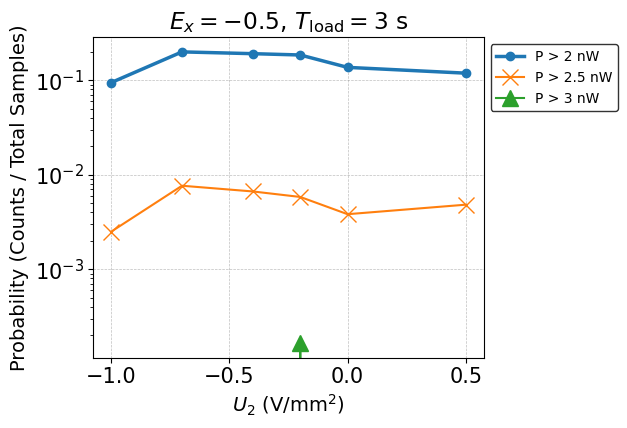

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Force clean, native Matplotlib styling
# plt.style.use('default')
big_plt_font()

# 1. Ensure coordinate arrays are structured as NumPy arrays
all_Ex = np.asarray(all_Ex)
all_T_load = np.asarray(all_T_load)
all_U2 = np.asarray(all_U2)

# 2. Filter data specifically for Ex = -0.5 and T_load = 3
target_indices = np.where((all_Ex == -0.5) & (all_T_load == 3))[0]

if len(target_indices) == 0:
    print("Error: No data records match the configuration Ex = -0.5 and T_load = 3.")
else:
    # Extract the subset variables
    filtered_U2 = all_U2[target_indices]
    filtered_trials = [all_data_ROI[idx] for idx in target_indices]

    # CRITICAL SORT: Arrange data by U2 values so lines connect smoothly across the X-axis
    sort_order = np.argsort(filtered_U2)
    u2_plot = filtered_U2[sort_order]
    trials_plot = [filtered_trials[i] for i in sort_order]

    # 3. Compute probability counts for the 2.5, 3.0, and 3.5 nW variations
    counts_25 = []
    counts_30 = []
    counts_35 = []

    for trial in trials_plot:
        power = dBm_to_W(trial) * 1e9  # Convert to nW
        
        # Using np.sum() dynamically computes the total count elements passing the filter
        counts_25.append(np.sum(power > 2) / len(trial))
        counts_30.append(np.sum(power > 2.5) / len(trial))
        counts_35.append(np.sum(power > 3.0) / len(trial))

    # 4. Generate the targeted Matplotlib plot
    fig, ax = plt.subplots(figsize=(6.5, 4.5))  # Proportional dimensions engineered for single-slide spaces

    # Plot the line variations with unique tracking markers
    ax.plot(u2_plot, counts_25, marker='.', linestyle='-',label='P > 2 nW')
    ax.plot(u2_plot, counts_30, marker='x', linestyle='-', linewidth=1.5, label='P > 2.5 nW')
    ax.plot(u2_plot, counts_35, marker='^', linestyle='-', linewidth=1.5, label='P > 3 nW')

    # Formatting axis labels and titles using standard Matplotlib syntax
    ax.set_xlabel("$U_2$ (V/mm$^2$)")
    ax.set_ylabel("Probability (Counts / Total Samples)")
    ax.set_title("$E_x = -0.5$, $T_{\\text{load}} = 3$ s")
    
    # Apply log scaling to the Y-axis to match your previous layout configuration
    ax.set_yscale('log')
    
    # Configure precise Matplotlib grid lines behind the data paths
    ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    
    # Clean up bounds, legends, ticks, and spine framing
    ax.legend(bbox_to_anchor=(1,1), frameon=True, edgecolor='black', fontsize=10)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_visible(True)

    plt.tight_layout()
    plt.show()

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def create_interactive_grid_plot(all_Ex, all_U2, all_T_load, all_data_ROI):
    # --- 1. HANDLE INHOMOGENEOUS / RAGGED DATA LINES ---
    lengths = []
    
    # Check if all_data_ROI is a NumPy array of objects or a nested Python list
    if isinstance(all_data_ROI, np.ndarray) and all_data_ROI.dtype == object:
        # Find minimum length across the object array grid
        for i in range(all_data_ROI.shape[0]):
            for j in range(all_data_ROI.shape[1]):
                for k in range(all_data_ROI.shape[2]):
                    lengths.append(len(all_data_ROI[i, j, k]))
        min_len = min(lengths)
        
        # Build a uniform dense 4D numerical array
        dense_ROI = np.empty((all_data_ROI.shape[0], all_data_ROI.shape[1], all_data_ROI.shape[2], min_len))
        for i in range(all_data_ROI.shape[0]):
            for j in range(all_data_ROI.shape[1]):
                for k in range(all_data_ROI.shape[2]):
                    dense_ROI[i, j, k, :] = all_data_ROI[i, j, k][:min_len]
        all_data_ROI = dense_ROI
        
    else:
        # Find minimum length across a nested Python list structure
        for i in range(len(all_data_ROI)):
            for j in range(len(all_data_ROI[i])):
                for k in range(len(all_data_ROI[i][j])):
                    lengths.append(len(all_data_ROI[i][j][k]))
        min_len = min(lengths)
        
        # Reconstruct and truncate the nested list structure
        truncated_list = []
        for i in range(len(all_data_ROI)):
            row_i = []
            for j in range(len(all_data_ROI[i])):
                row_j = []
                for k in range(len(all_data_ROI[i][j])):
                    row_j.append(all_data_ROI[i][j][k][:min_len])
                row_i.append(row_j)
            truncated_list.append(row_i)
        all_data_ROI = np.array(truncated_list)

    print(f"Data successfully truncated! All curves normalized to a length of {min_len} samples.")

    # Convert coordinate variables safely to standard NumPy arrays
    all_Ex = np.asarray(all_Ex)
    all_U2 = np.asarray(all_U2)
    all_T_load = np.asarray(all_T_load)

    # --- 2. DEFINE SELECTION WIDGETS ---
    ex_widget = widgets.SelectMultiple(
        options=list(np.unique(all_Ex)),
        value=[np.unique(all_Ex)[0]],  
        description='$E_x$ (Multi):',
        style={'description_width': 'initial'}
    )
    
    u2_widget = widgets.Dropdown(
        options=list(np.unique(all_U2)),
        value=np.unique(all_U2)[0],
        description='$U_2$:',
    )
    
    t_widget = widgets.Dropdown(
        options=list(np.unique(all_T_load)),
        value=np.unique(all_T_load)[0],
        description='$T_{\\text{load}}$:',
    )
    
    display_mode = widgets.RadioButtons(
        options=['Raw ROI Curves', 'Statistical Metrics'],
        value='Raw ROI Curves',
        description='View Mode:'
    )

    # --- 3. DASHBOARD UPDATE CALLBACK ---
    def update_dashboard(selected_ex, chosen_u2, chosen_t, view_mode):
        if not selected_ex:
            print("Please select at least one E_x value (Hold Ctrl/Cmd to select multiple).")
            return
            
        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Find exact matrix indices matching the dropdown values
        idx_u2 = np.where(all_U2 == chosen_u2)[0][0]
        idx_t = np.where(all_T_load == chosen_t)[0][0]
        
        if view_mode == 'Raw ROI Curves':
            # Plot raw signal arrays
            for ex_val in selected_ex:
                idx_ex = np.where(all_Ex == ex_val)[0][0]
                curve_data = all_data_ROI[idx_ex, idx_u2, idx_t, :]
                
                ax.plot(curve_data, label=f'$E_x$={ex_val}')
                
            ax.set_xlabel("Sample Index")
            ax.set_ylabel("ROI Amplitude")
            ax.set_title(f"Raw ROI Signals ($U_2$={chosen_u2}, $T_{{\\text{{load}}}}$={chosen_t})")
            
        else:
            # Grouped bar chart for Mean, Std, Max, Min metrics
            x_positions = np.arange(len(selected_ex))
            width = 0.2
            
            means, stds, maxs, mins = [], [], [], []
            for ex_val in selected_ex:
                idx_ex = np.where(all_Ex == ex_val)[0][0]
                curve_data = all_data_ROI[idx_ex, idx_u2, idx_t, :]
                means.append(np.mean(curve_data))
                stds.append(np.std(curve_data))
                maxs.append(np.max(curve_data))
                mins.append(np.min(curve_data))
                
            ax.bar(x_positions - 1.5*width, means, width, label='Mean ($\mu$)', color='#1f77b4')
            ax.bar(x_positions - 0.5*width, stds, width, label='Std ($\sigma$)', color='#ff7f0e')
            ax.bar(x_positions + 0.5*width, maxs, width, label='Max', color='#2ca02c')
            ax.bar(x_positions + 1.5*width, mins, width, label='Min', color='#d62728')
            
            ax.set_xticks(x_positions)
            ax.set_xticklabels([f'$E_x$={v}' for v in selected_ex])
            ax.set_ylabel("Metric Value")
            ax.set_title(f"Statistical Metrics Comparison ($U_2$={chosen_u2}, $T_{{\\text{{load}}}}$={chosen_t})")
            
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # --- 4. DISPLAY LAYOUT ---
    controls = widgets.VBox([ex_widget, u2_widget, t_widget, display_mode])
    plot_output = widgets.interactive_output(
        update_dashboard, 
        {'selected_ex': ex_widget, 'chosen_u2': u2_widget, 'chosen_t': t_widget, 'view_mode': display_mode}
    )
    
    display(widgets.HBox([controls, plot_output]))

In [214]:
create_interactive_grid_plot(all_Ex, all_U2, all_T_load, all_data_ROI)

TypeError: object of type 'numpy.float64' has no len()

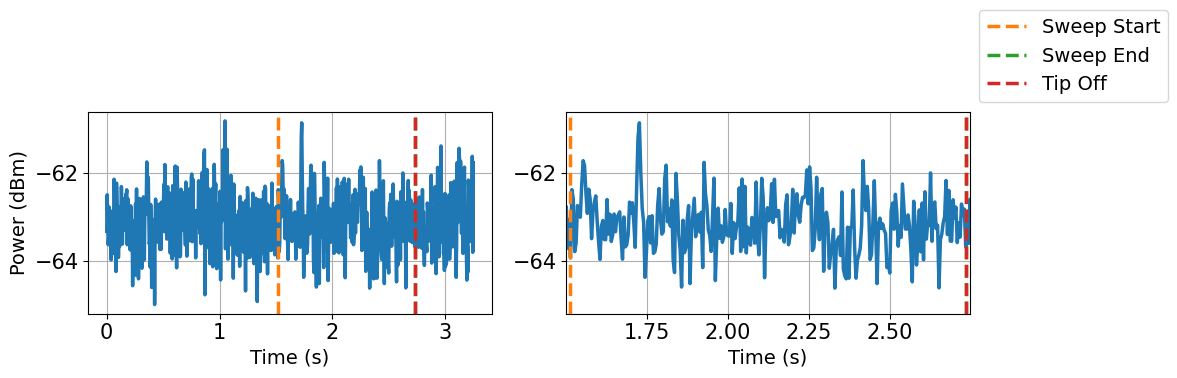

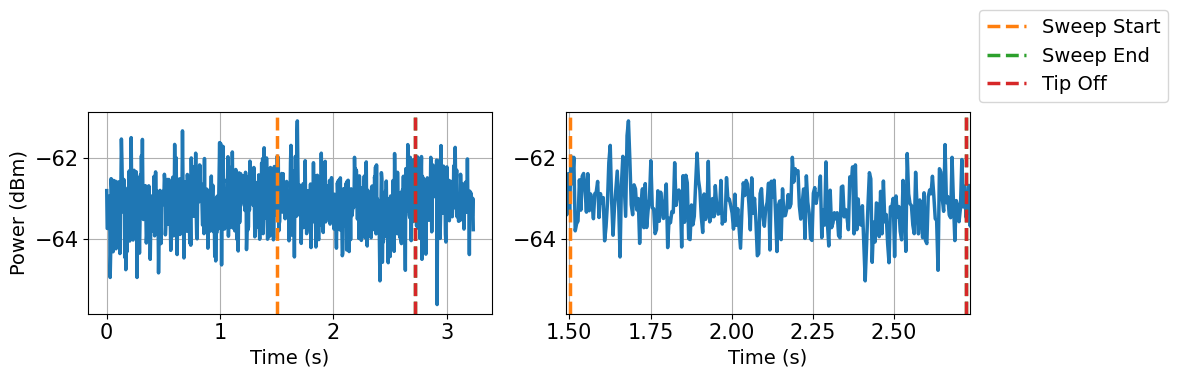

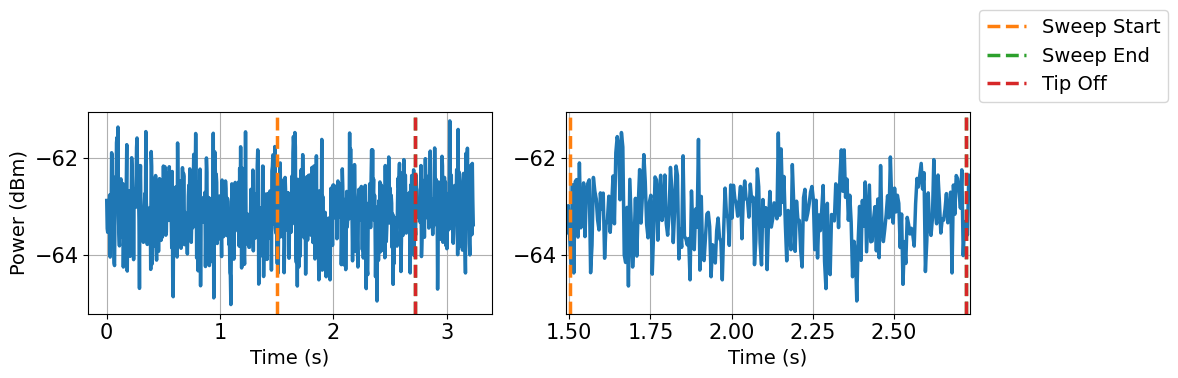

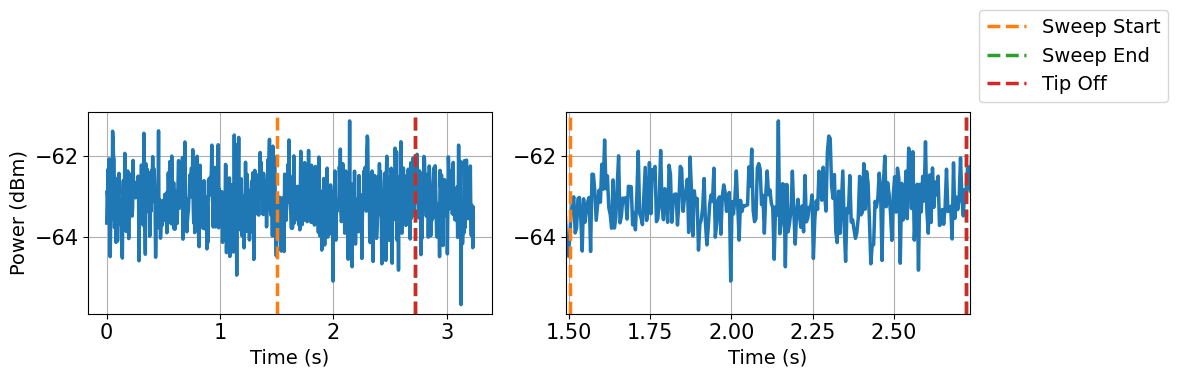

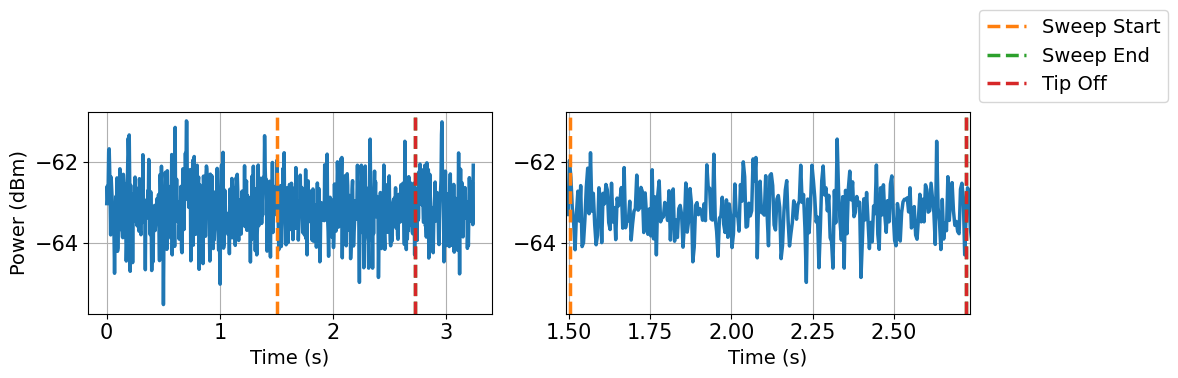

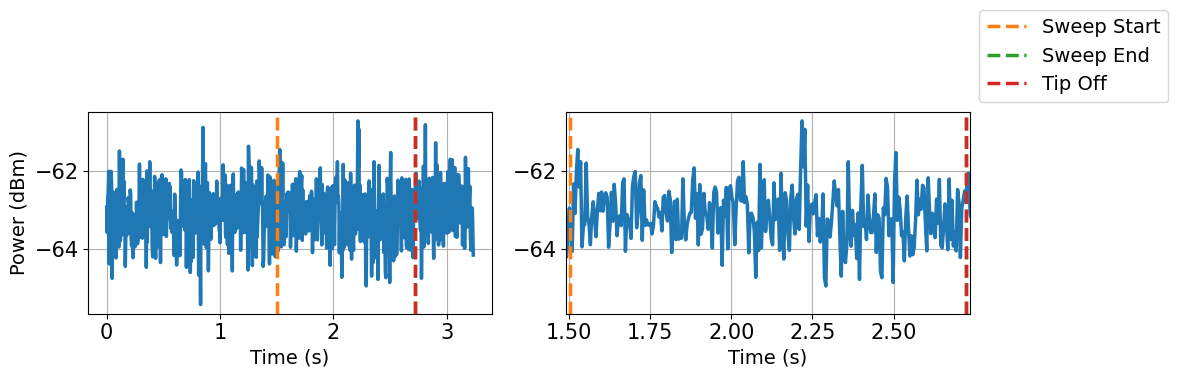

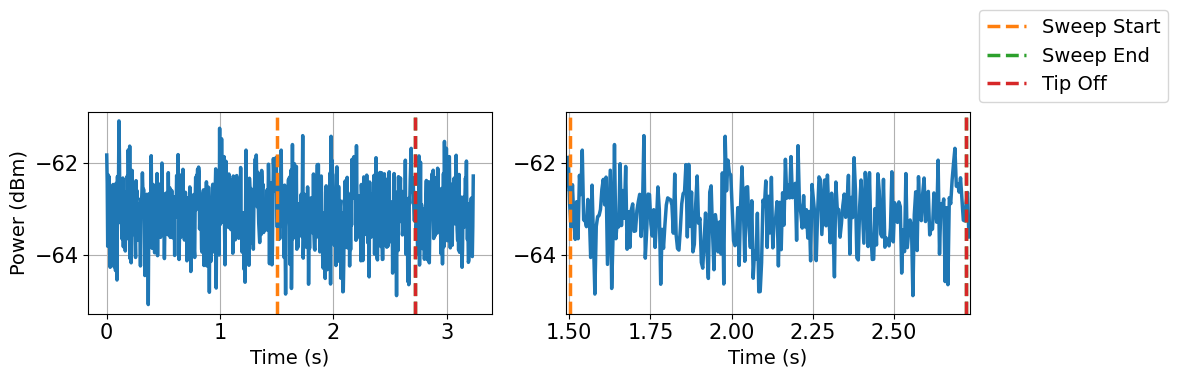

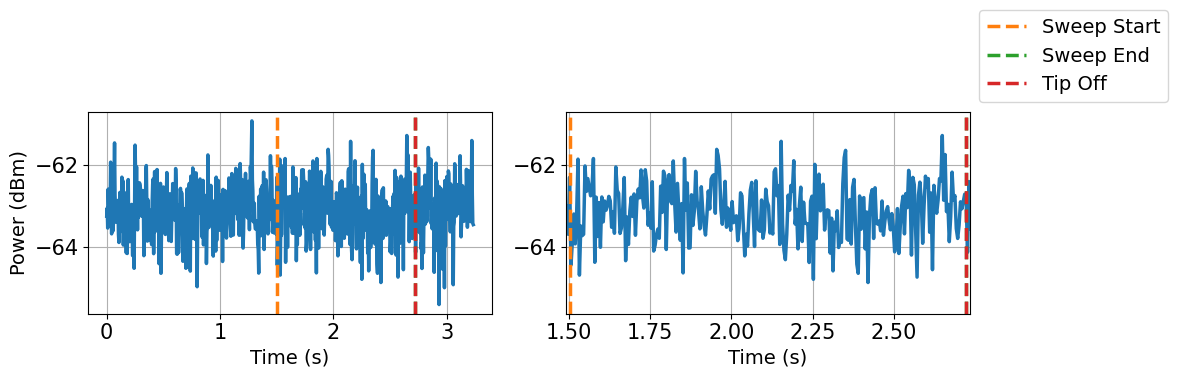

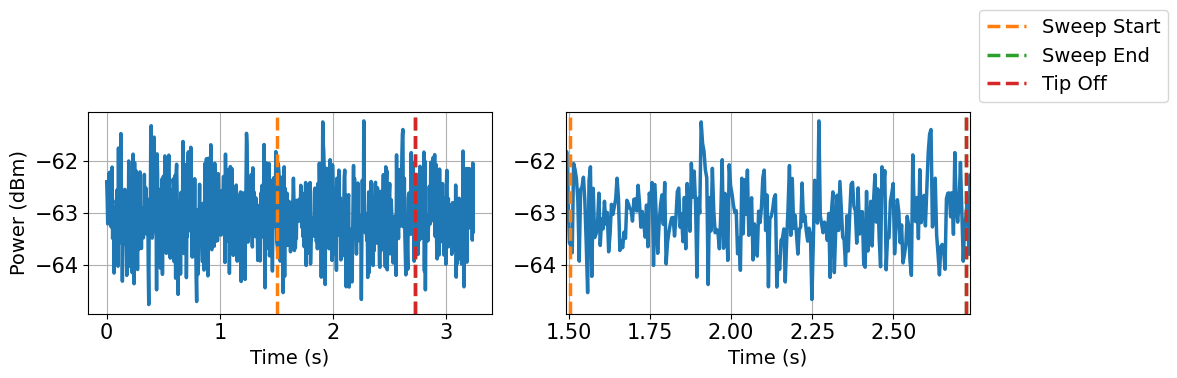

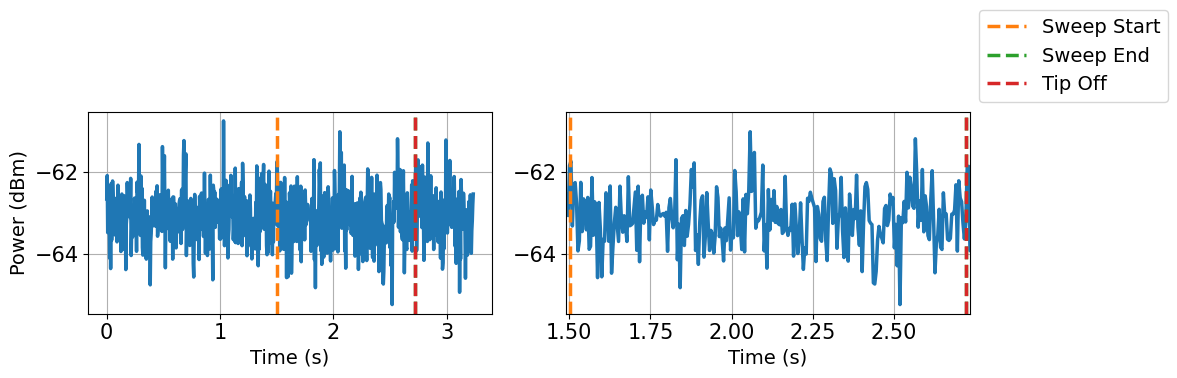

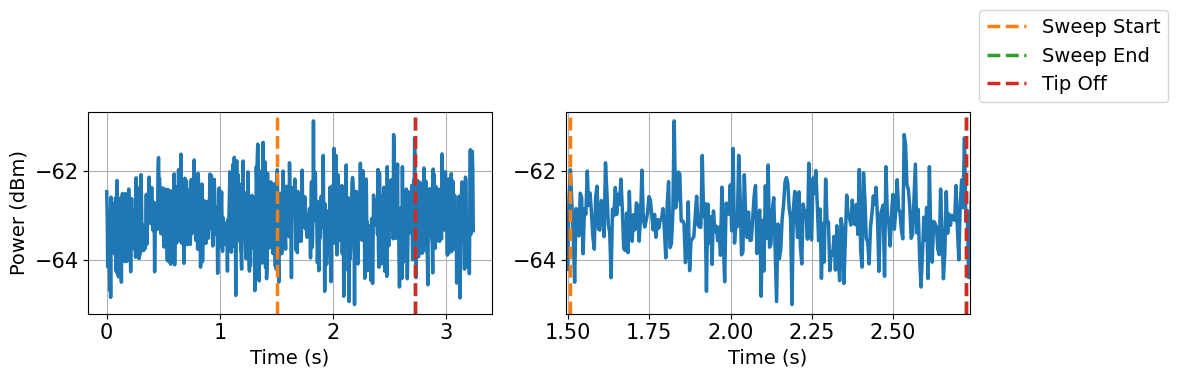

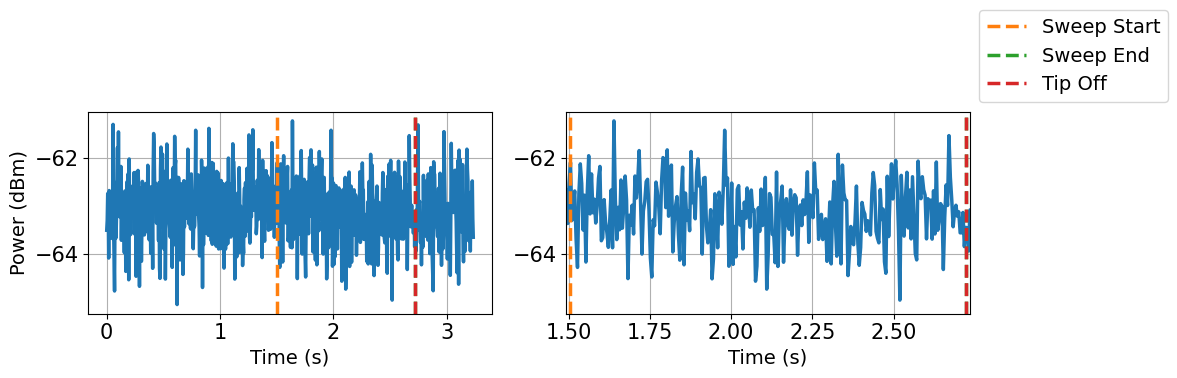

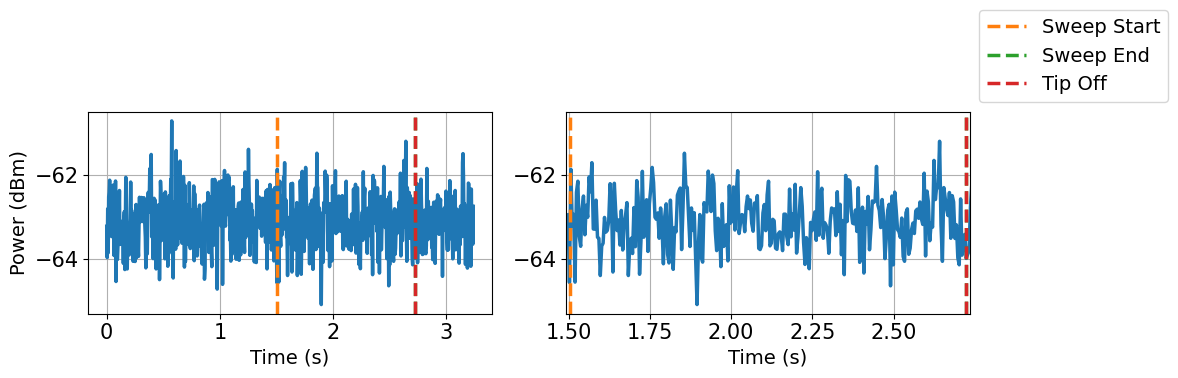

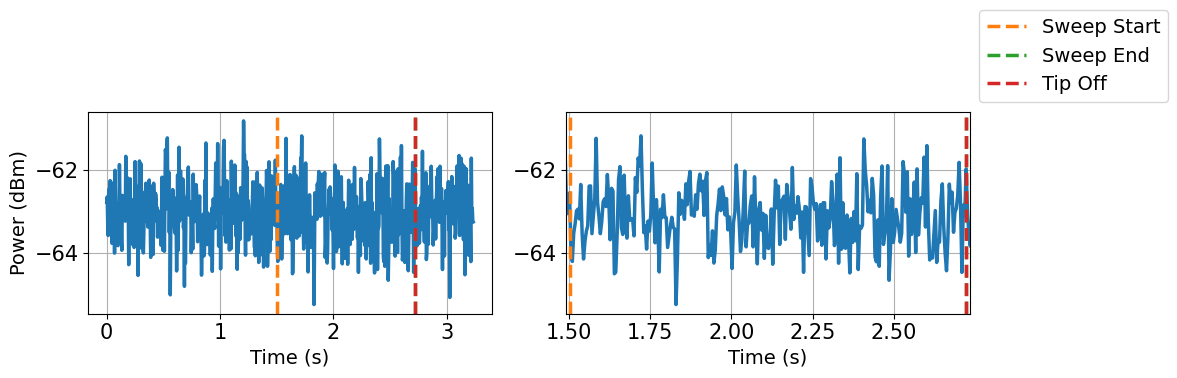

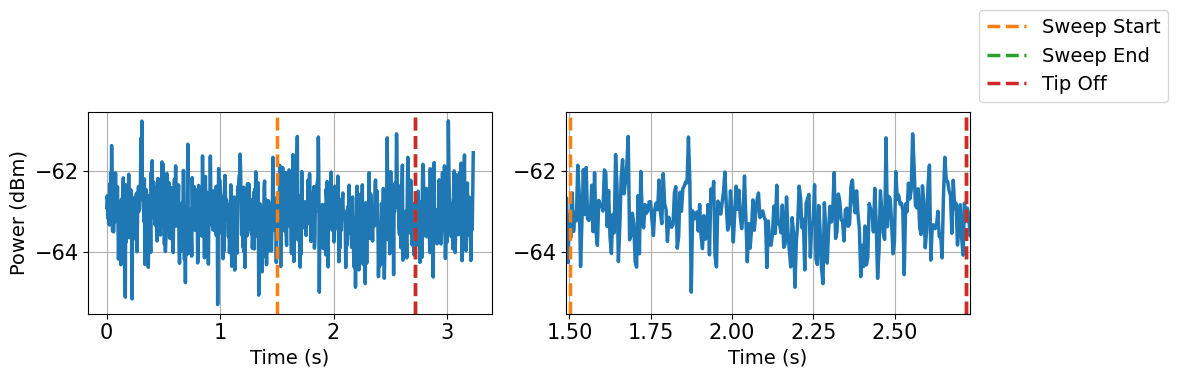

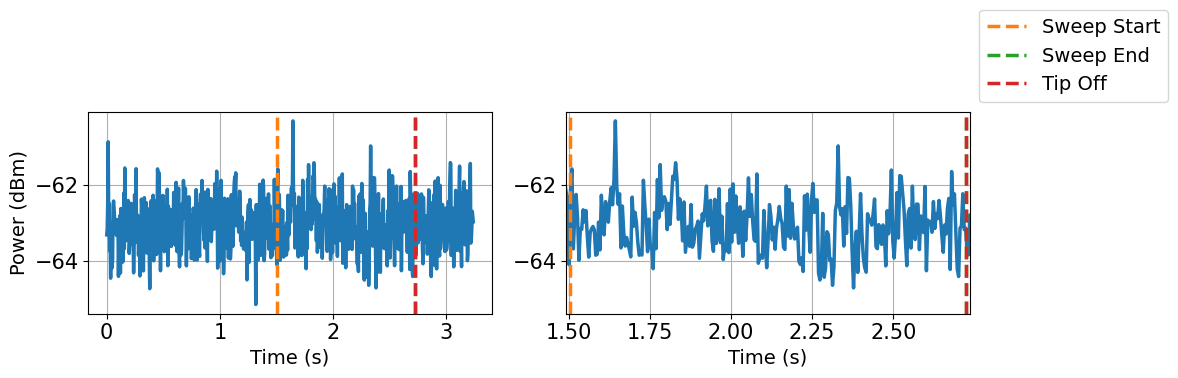

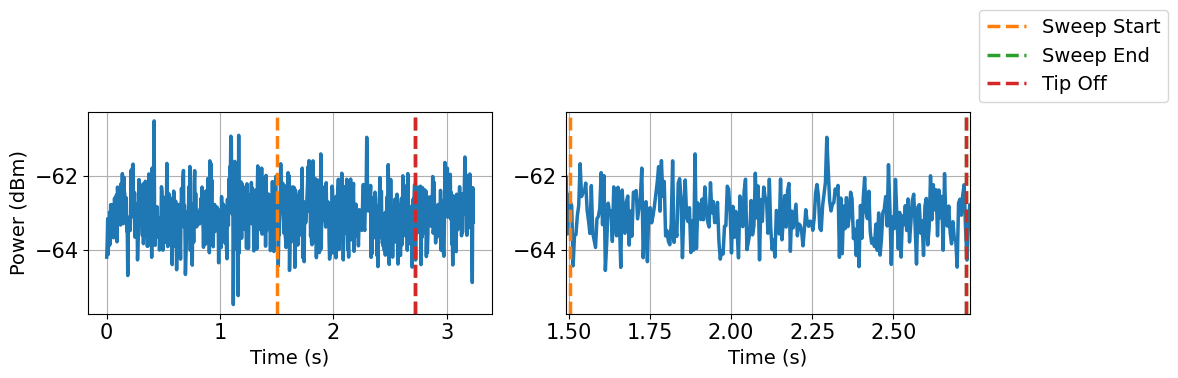

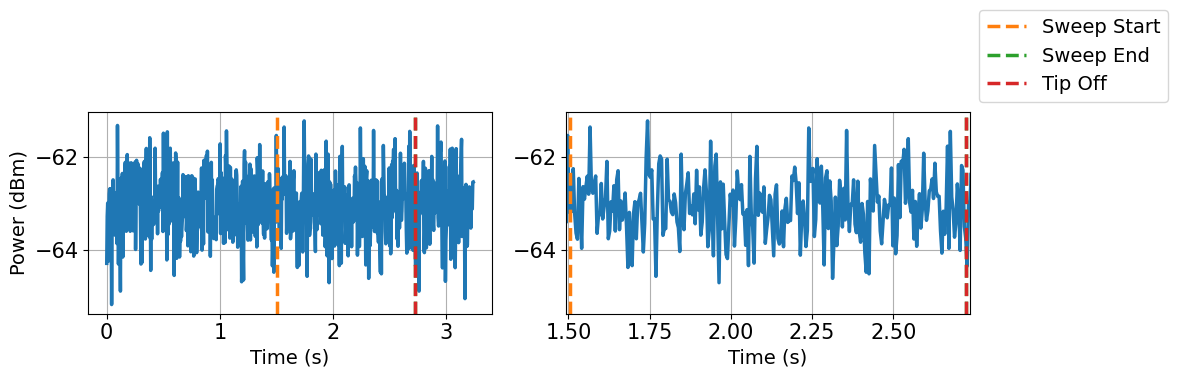

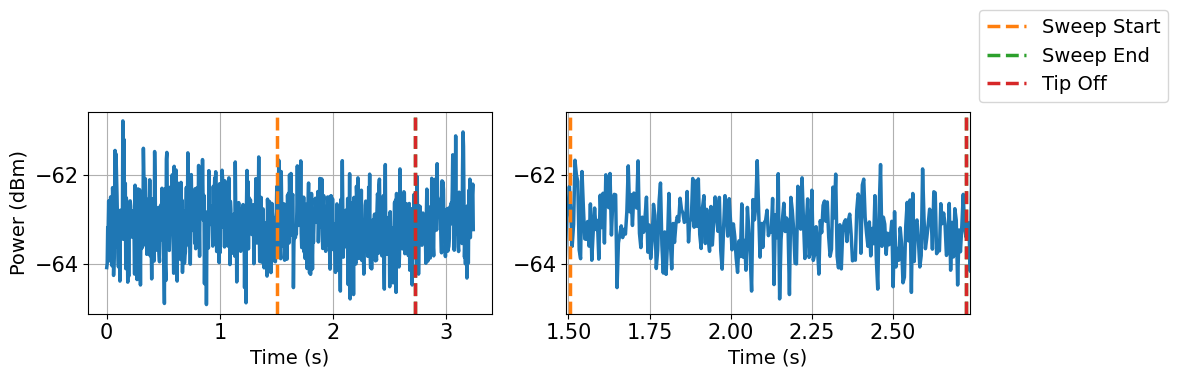

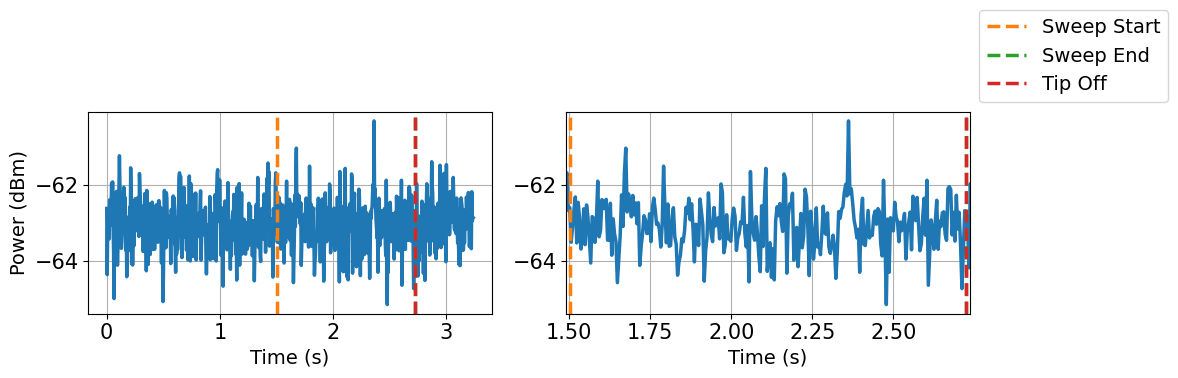

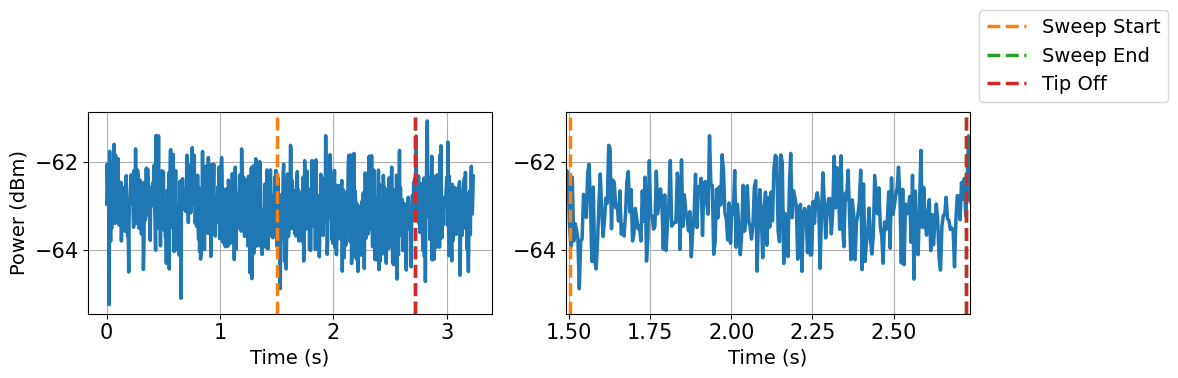

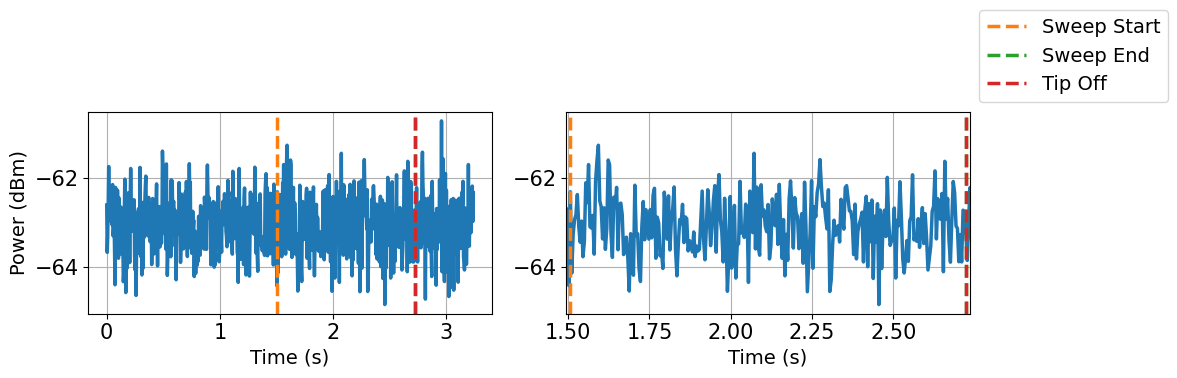

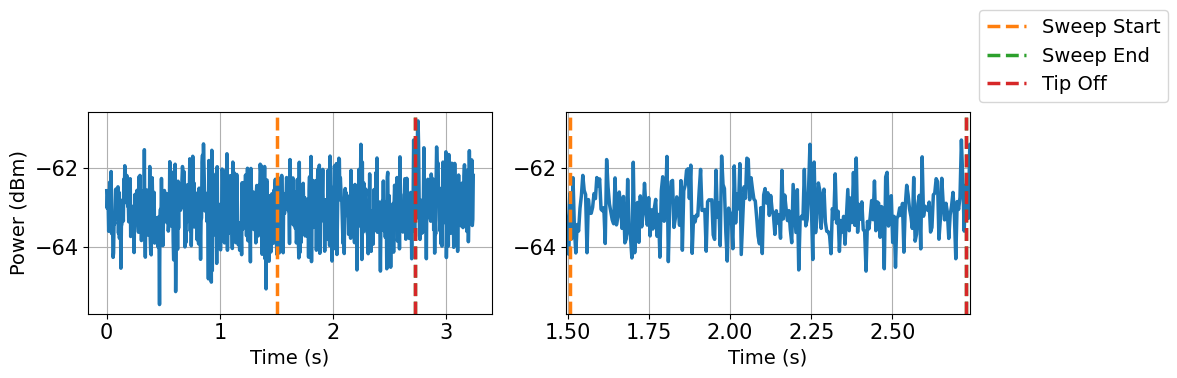

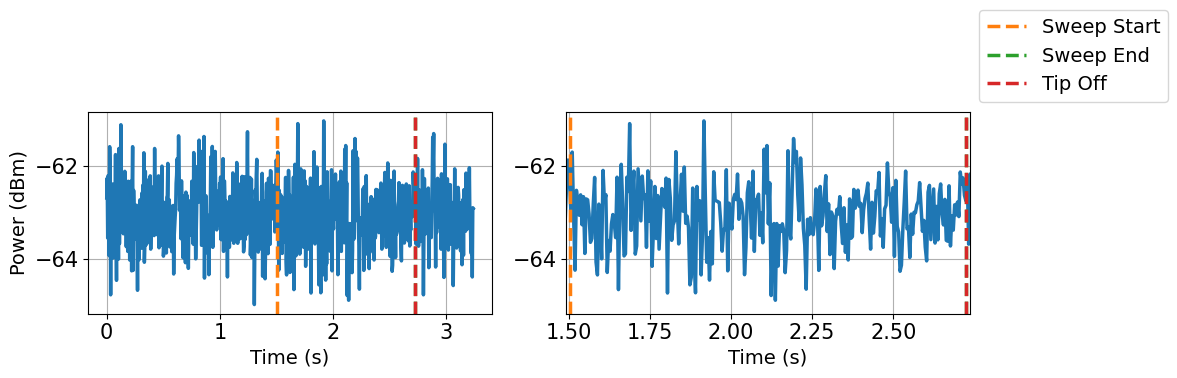

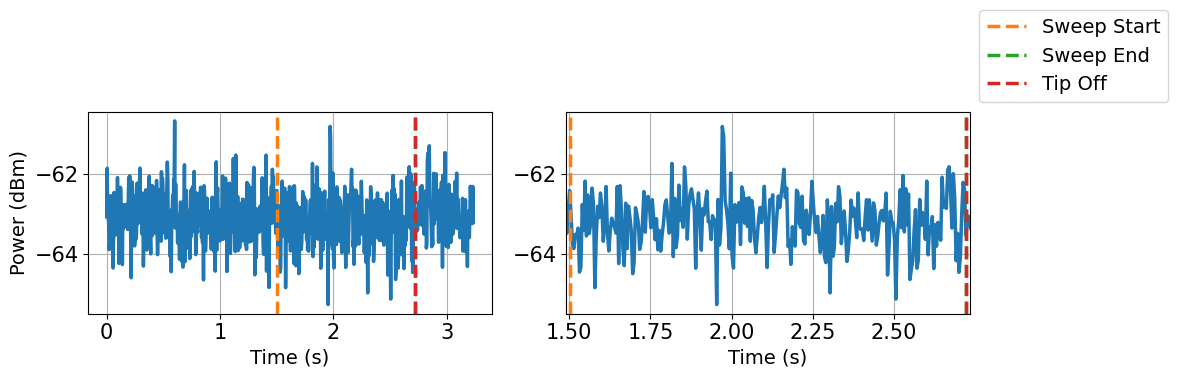

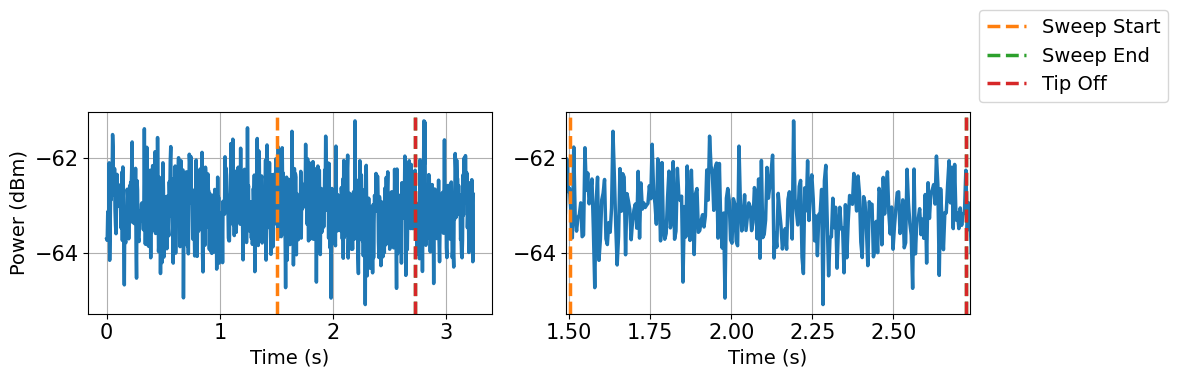

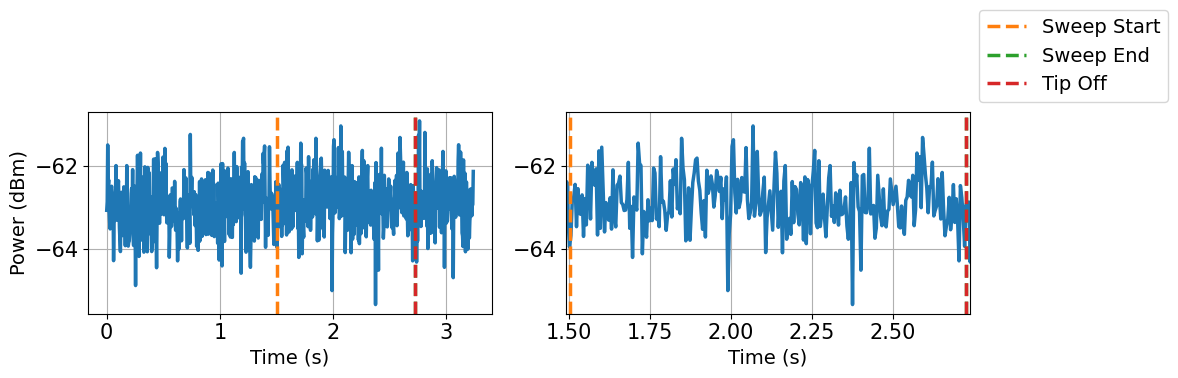

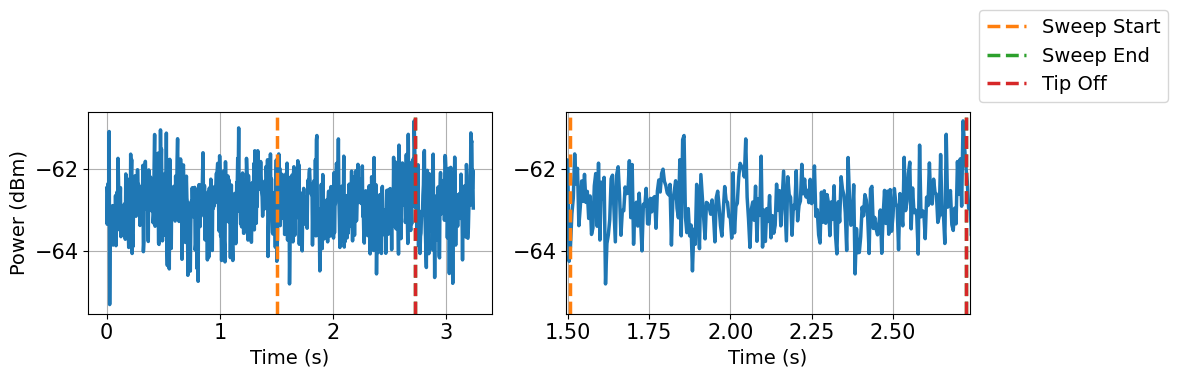

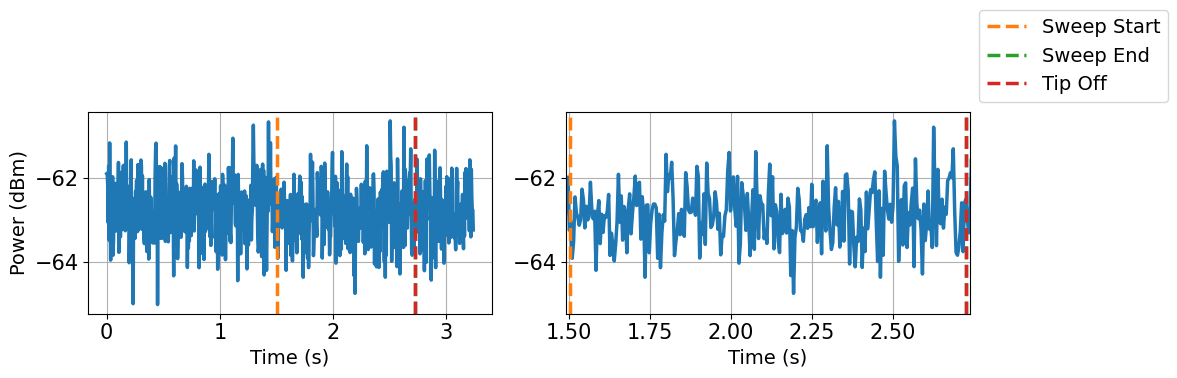

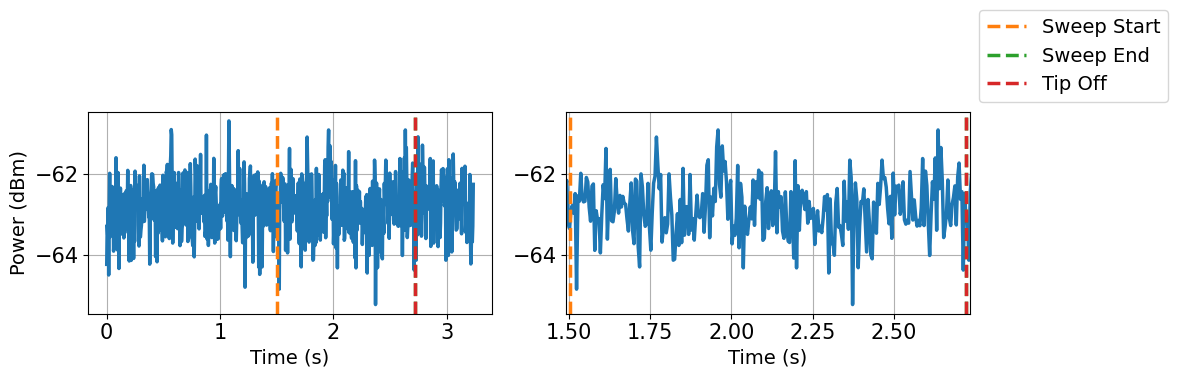

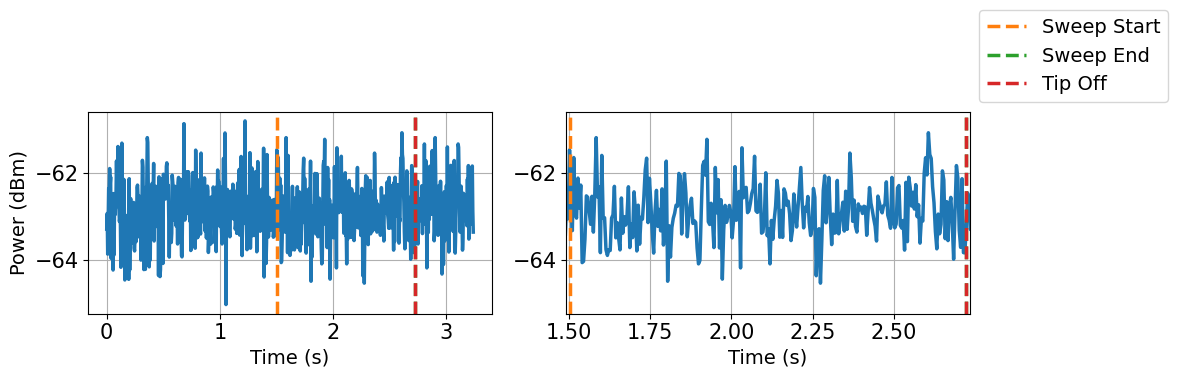

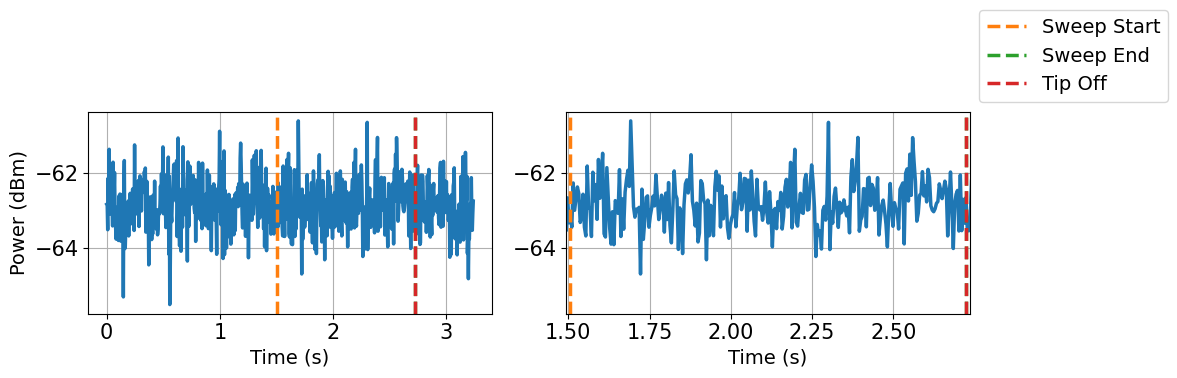

In [107]:
## Individual plottings

data = file['all_meas'] 
t_start = file['t_tip_on']
t_sweep_start = file['t_sweep_start'] - t_start
t_sweep_end = file['t_sweep_end'] - t_start 
t_tip_off = file['t_tip_off'] - t_start
t_seq_end = file['t_seq_end'] - t_start 
for i in range(len(data)):
    data_avg = data[i] 
    fig, ax = plt.subplots(ncols=2, figsize=(12,4))
    t_axis = np.linspace(0, t_seq_end[i], len(data_avg)) 
    T_zoom_expansion = max(2*(t_tip_off[i] - t_sweep_end[i]), 0.01)
    plot_ax(ax[0], t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')
    plot_ax(ax[1], t_axis, data_avg, xlabel='Time (s)')
    ax[0].axvline(t_sweep_start[i], linestyle='--', c='C1', label='Sweep Start')
    ax[0].axvline(t_sweep_end[i], linestyle='--', c='C2', label='Sweep End') 
    ax[0].axvline(t_tip_off[i], linestyle='--', c='C3', label='Tip Off') 
    ax[1].axvline(t_sweep_start[i], linestyle='--', c='C1', label='Sweep Start')
    ax[1].axvline(t_sweep_end[i], linestyle='--', c='C2', label='Sweep End') 
    ax[1].axvline(t_tip_off[i], linestyle='--', c='C3', label='Tip Off') 
    ax[1].set_xlim((t_sweep_start[i]-T_zoom_expansion, t_tip_off[i]+T_zoom_expansion))
    ax[1].legend(bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

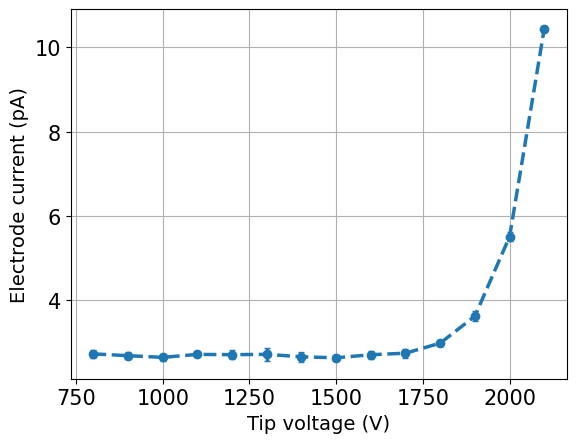

In [32]:
file = load_latest_data() 
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

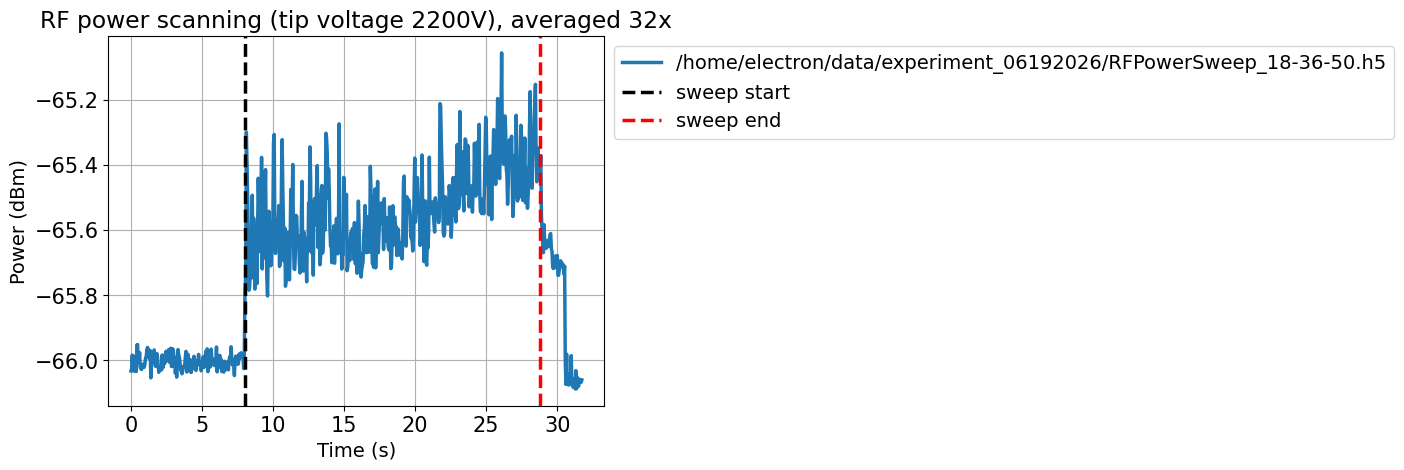

In [33]:
file = load_latest_data()
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


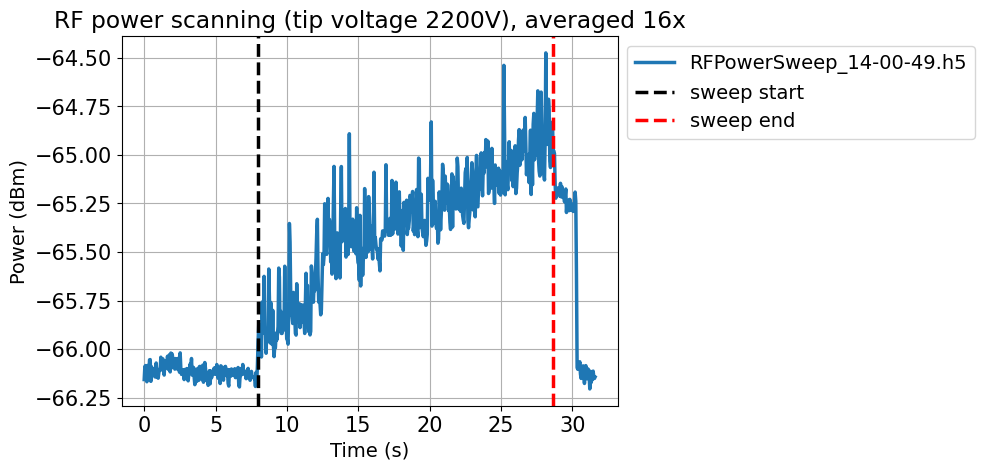

In [13]:

file = load_h5_data('RFPowerSweep_13-35-03.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label='RFPowerSweep_14-00-49.h5', title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


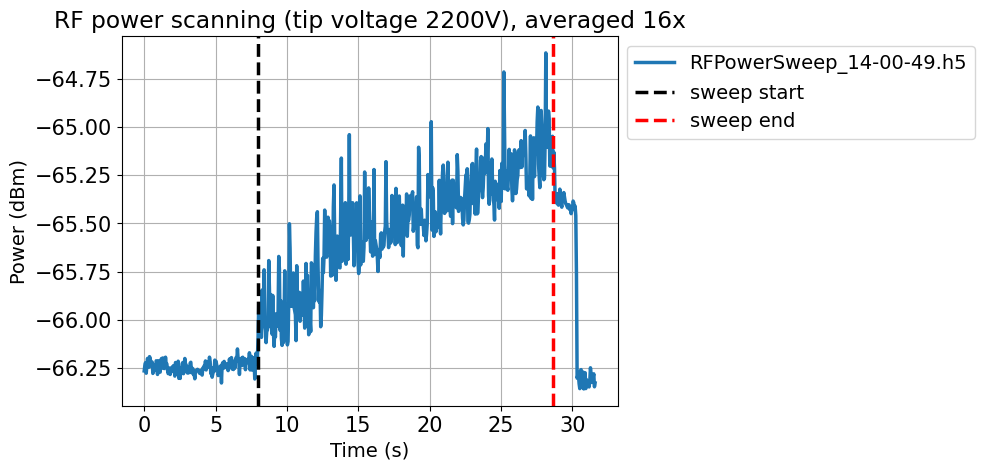

In [14]:

file = load_h5_data('RFPowerSweep_14-00-49.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
all_data = file['all_meas']
num_points = len(all_data[0])
t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label='RFPowerSweep_14-00-49.h5', title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


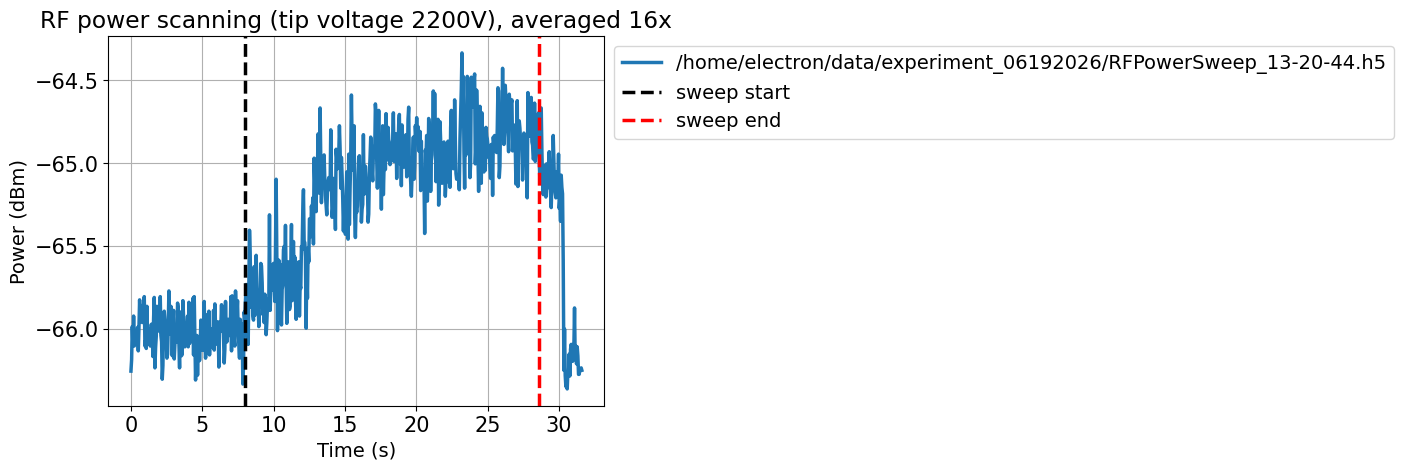

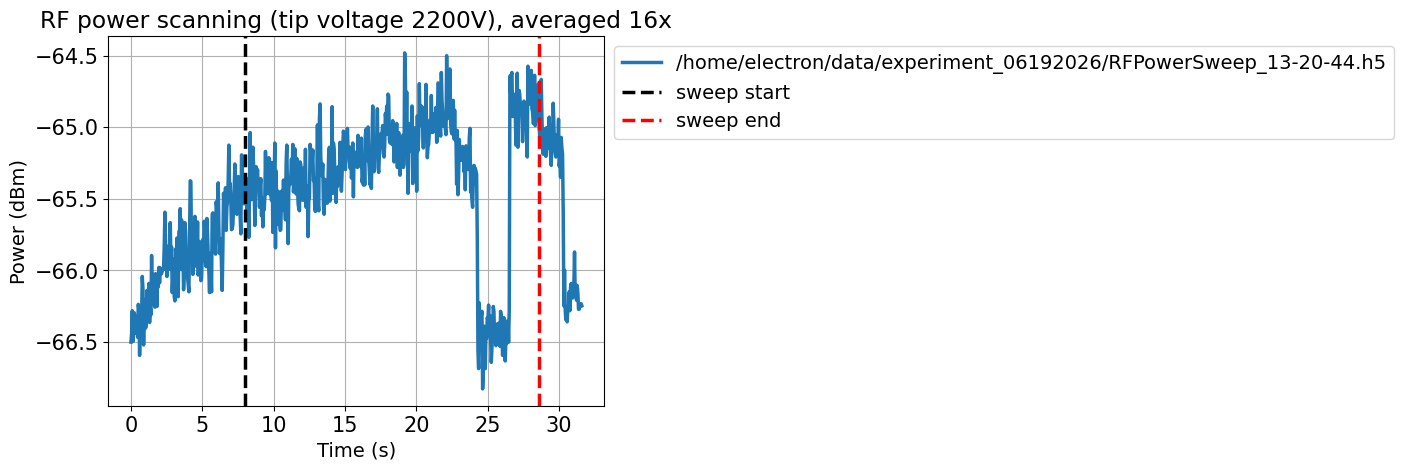

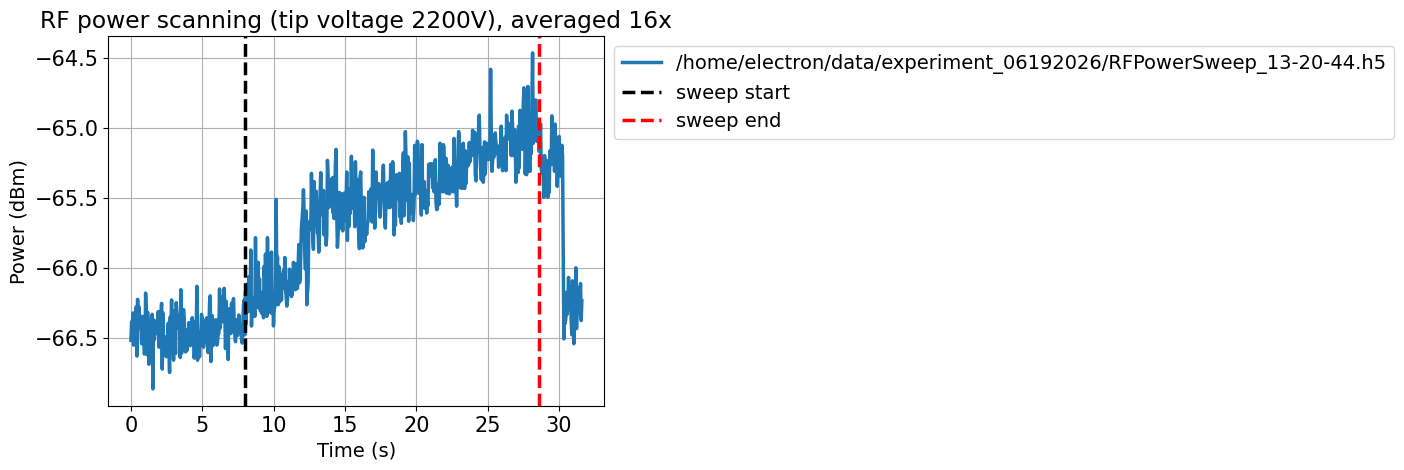

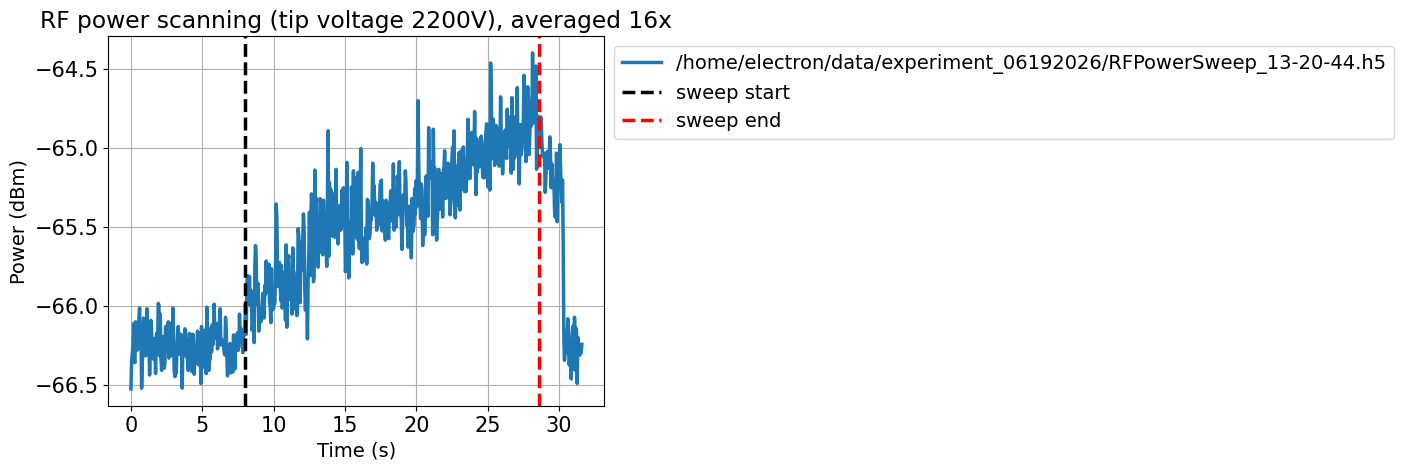

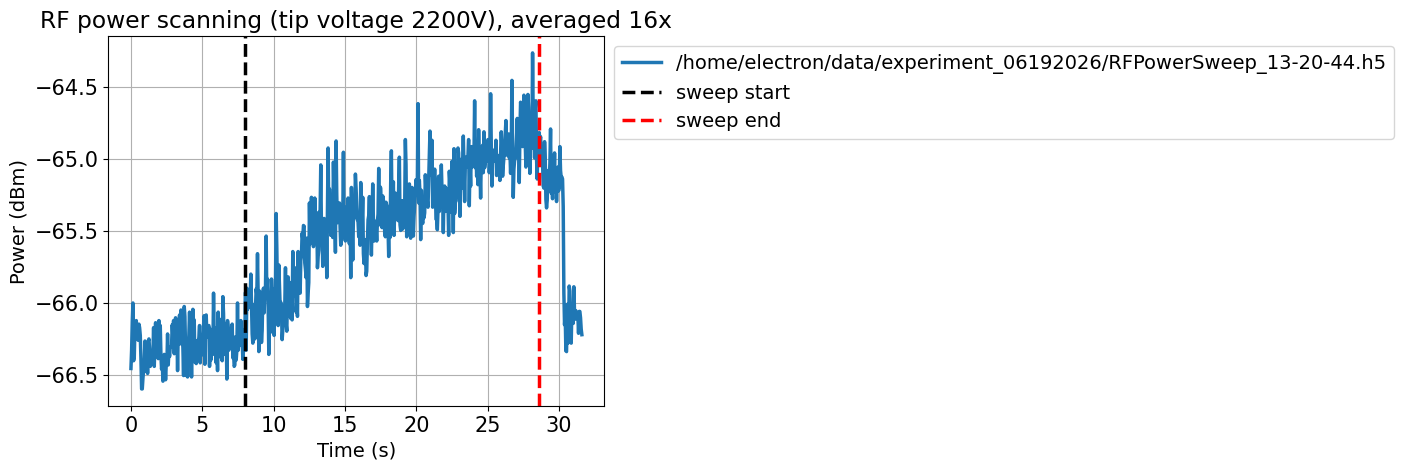

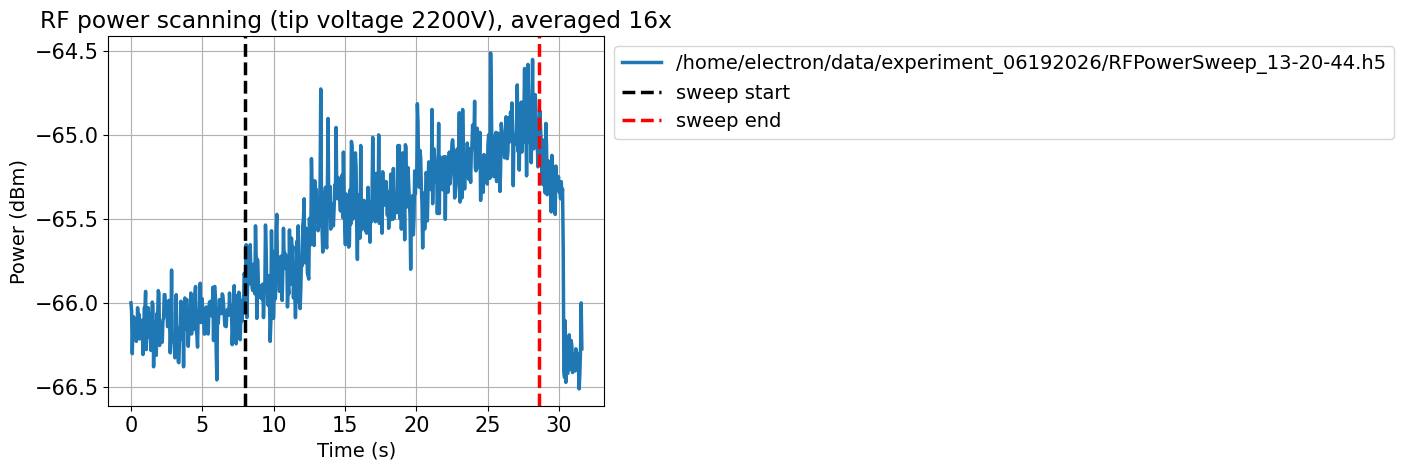

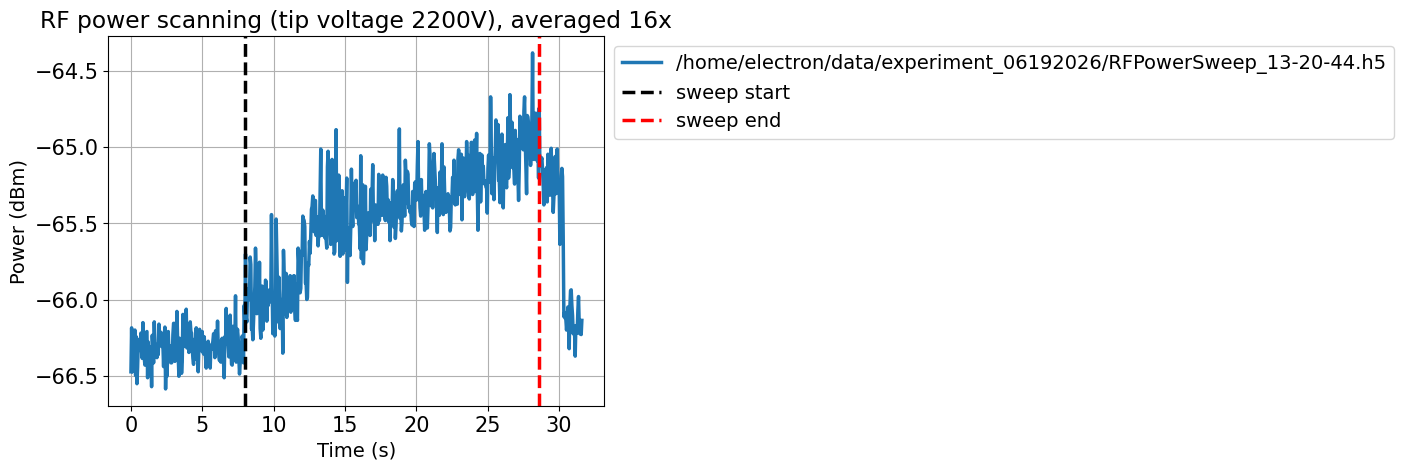

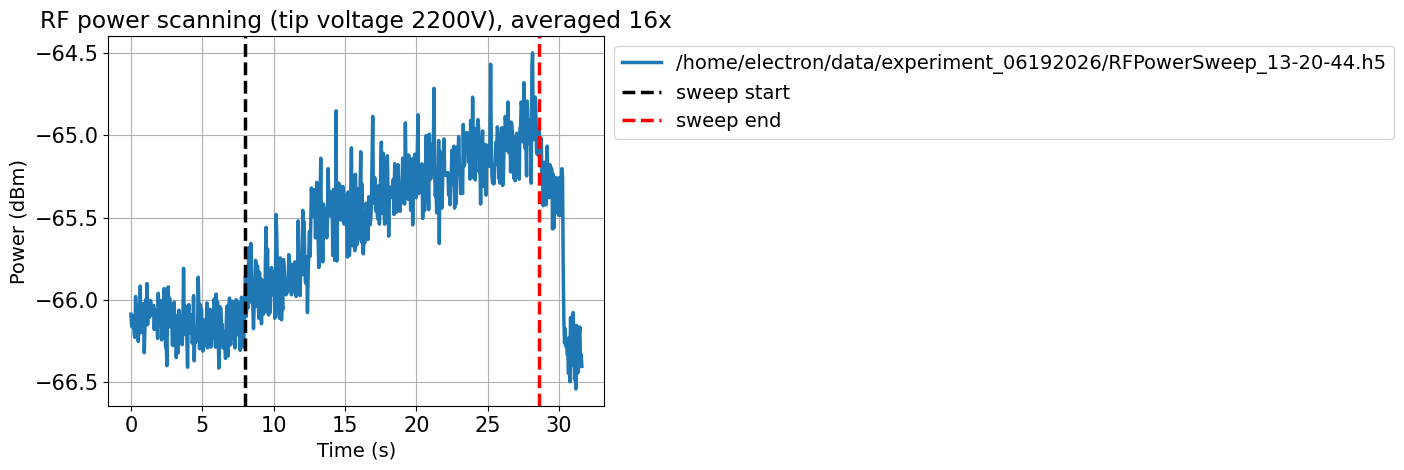

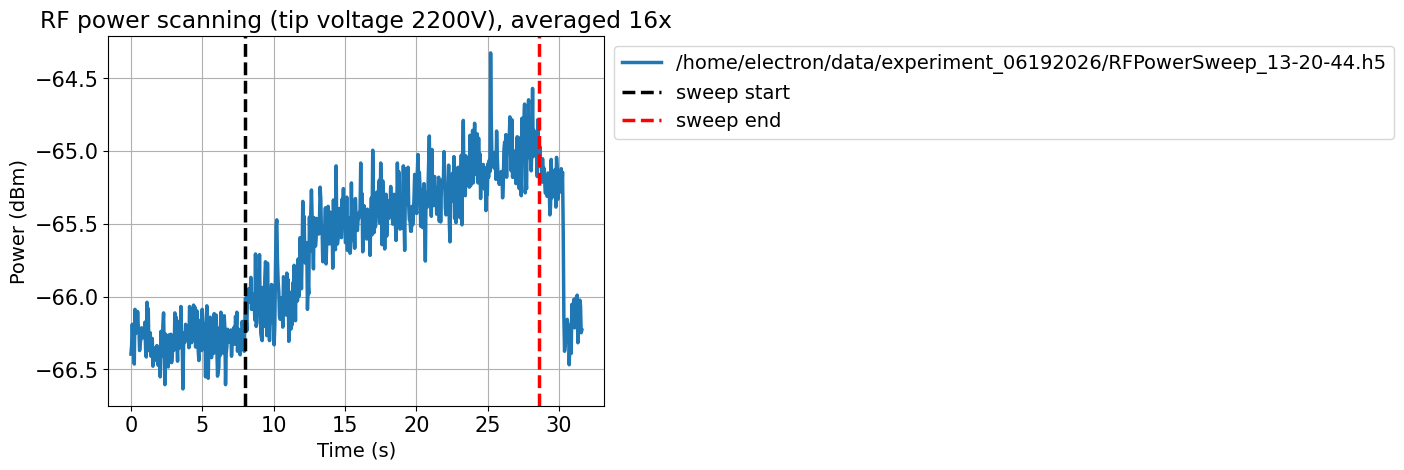

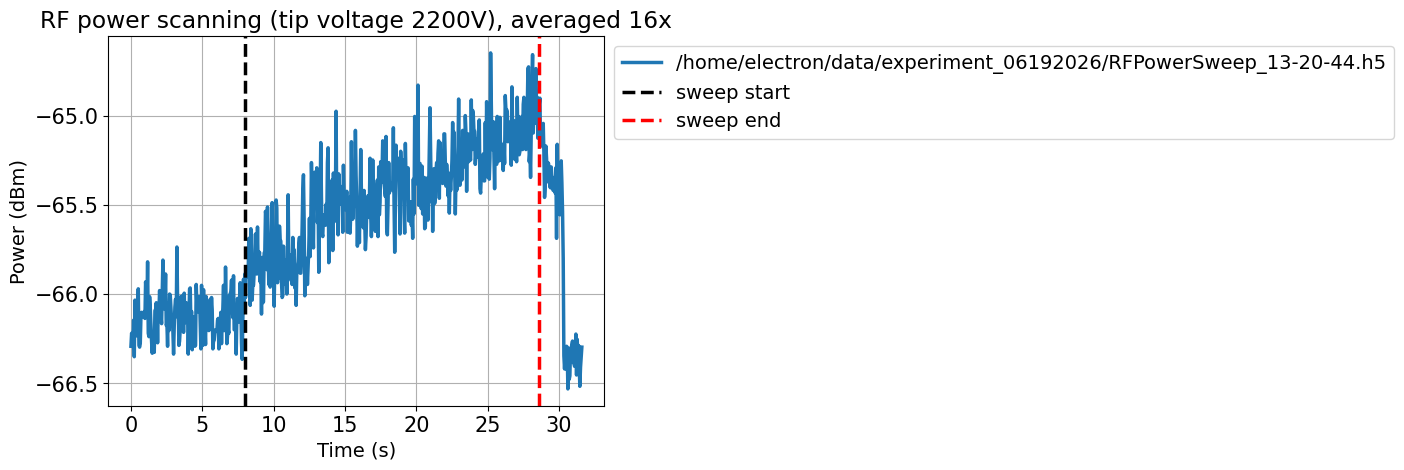

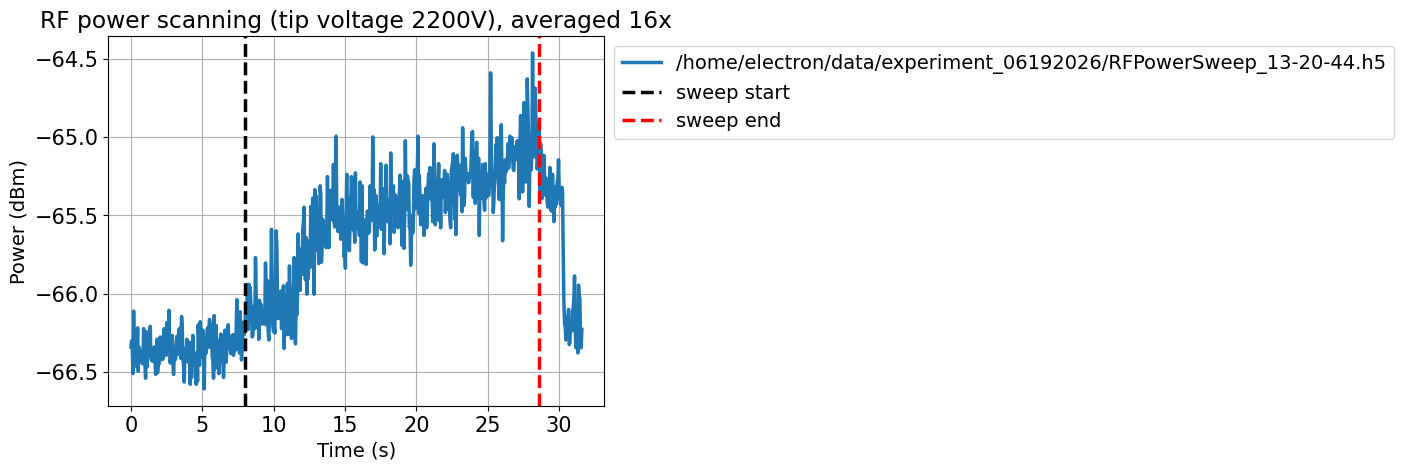

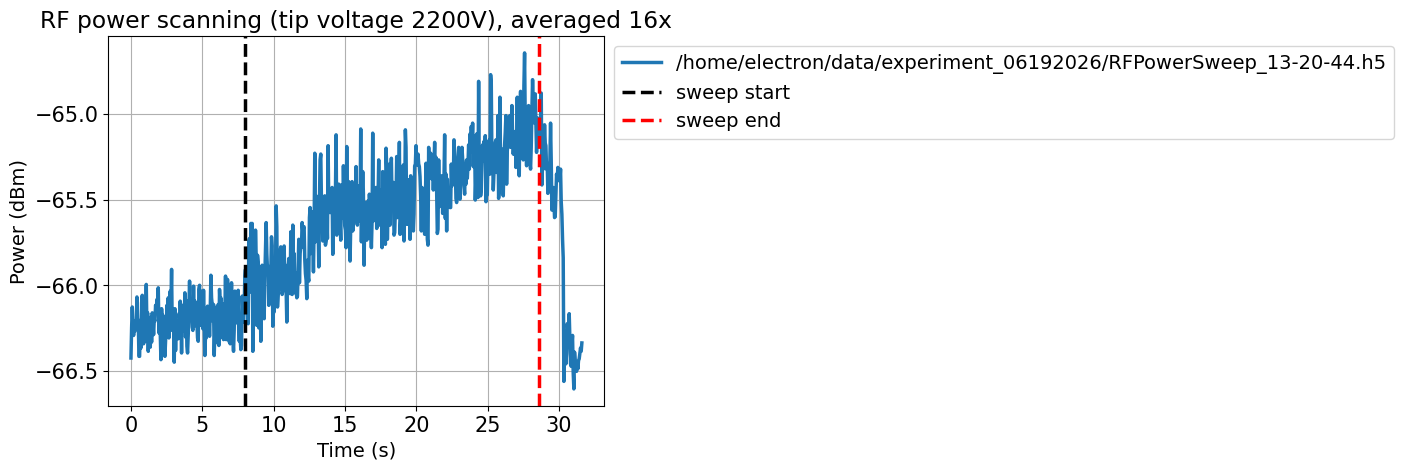

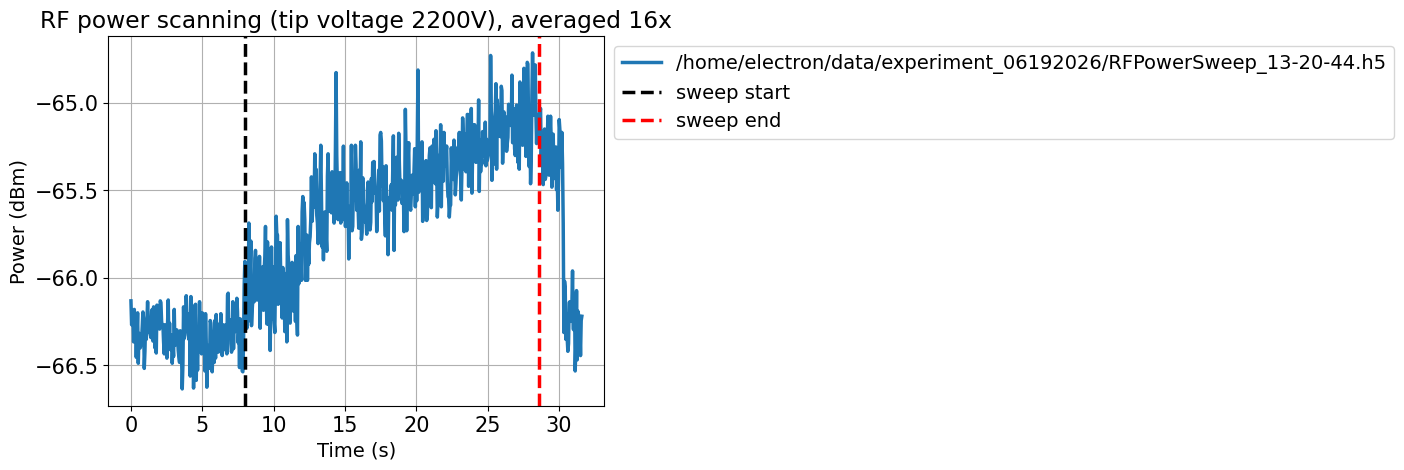

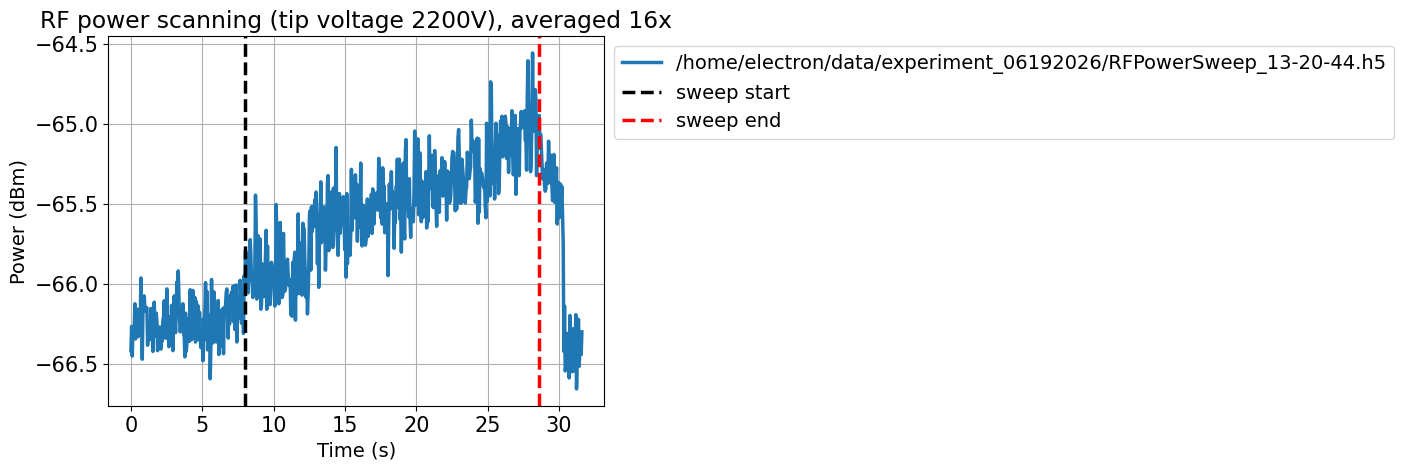

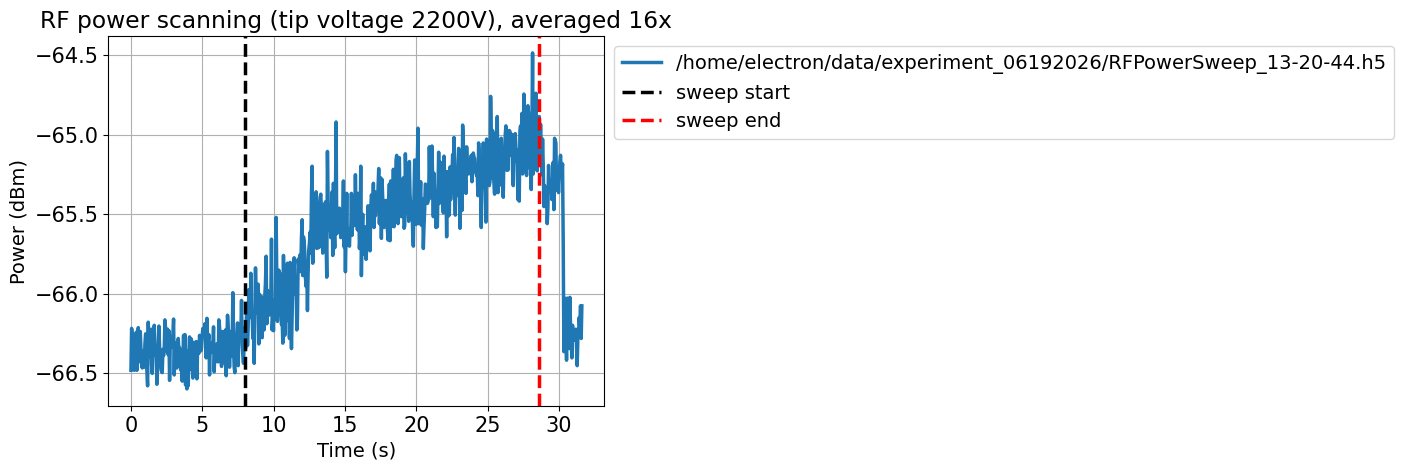

In [25]:
file = load_latest_data()
for i in range(len(file['all_meas'])-1):
    all_data = file['all_meas'][i:i+1]
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay']-1)
    plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
         ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}V), averaged {file['N_avg']}x")
    plt.axvline(file['t_valon_settle'], linestyle='--', color='k', label='sweep start')
    plt.axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='r', label='sweep end') 
    # plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
    # plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
    plt.legend(bbox_to_anchor=(1,1))
    plt.show()


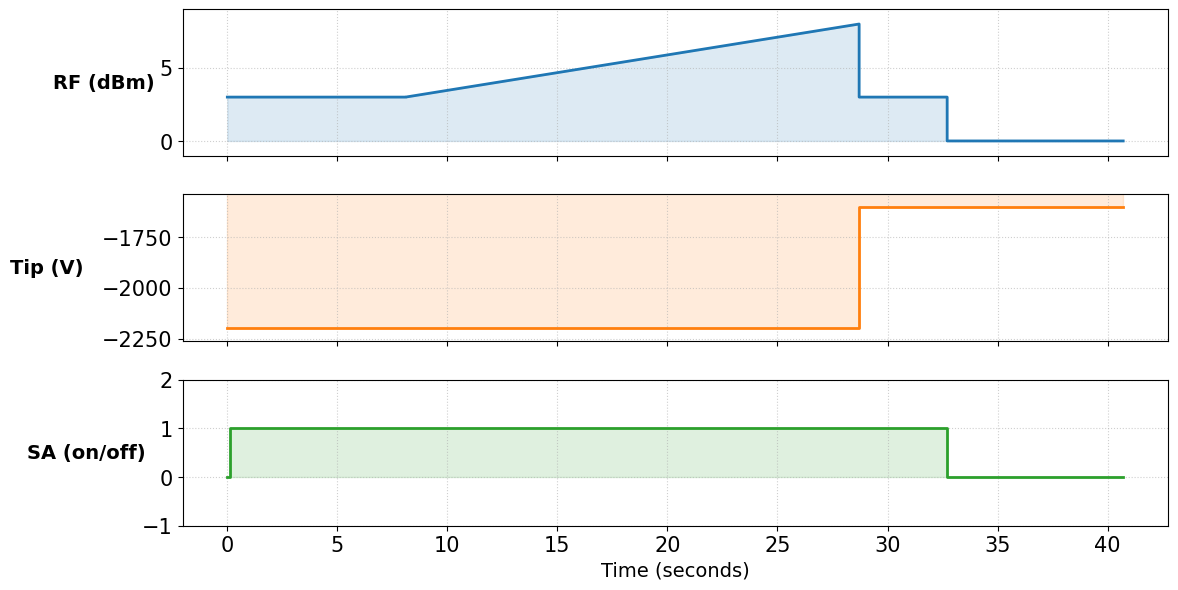

In [18]:
# --- Program Your Sequence Here ---
rf_program = [
    ('flat', 0.1, file['dBm_scan'][0]),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], file['dBm_scan'][0]),               
    ('linear_sweep', file['t_end'][-1]-file['t_start'][-1], 3.0, 8.0),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], file['dBm_scan'][0]),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], 0.0)                 # Goes to 0 for 8s
]
tip = [
    ('flat', 0.1, -file['V_on']),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], -file['V_on']),               
    ('flat', file['t_end'][-1]-file['t_start'][-1], -file['V_on']),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], -file['V_off']),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], -file['V_off'])                 # Goes to 0 for 8s
]
SSA = [
    ('flat', 0.1, 0),                # Value is 3 at time 1s (0s to 1s)
    ('flat', file['t_valon_settle'], 1),               
    ('flat', file['t_end'][-1]-file['t_start'][-1], 1),  # Sweeps from 3 to 8 for 20s
    ('flat', file['t_meas_delay'], 1),                # Drops back to 3 for 1s
    ('flat', file['t_valon_settle'], 0)                 # Goes to 0 for 8s
]

# Compile the program into raw timeline data
compiled_signals = {
    "RF (dBm)": generate_signal_timeline(rf_program),
    "Tip (V)": generate_signal_timeline(tip), 
    "SA (on/off)": generate_signal_timeline(SSA)
}

# Plot the result
plot_generated_timelines(compiled_signals)

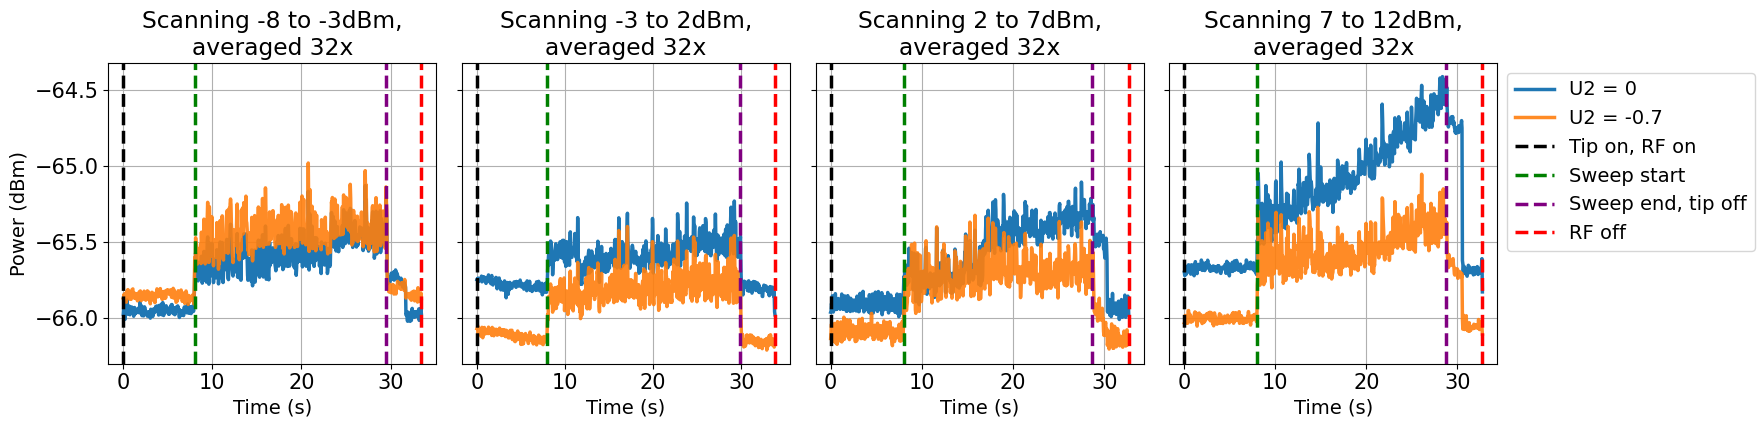

In [8]:
files = ['RFPowerSweep_17-24-48', 'RFPowerSweep_17-49-11', 'RFPowerSweep_18-12-59', 'RFPowerSweep_18-36-50']
files2 = ['RFPowerSweep_15-00-25', 'RFPowerSweep_15-24-49', 'RFPowerSweep_15-48-37', 'RFPowerSweep_16-12-27']
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(18,4.5))
for i in range(4):
    filename = files2[i]
    file = load_h5_data(filename+'.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
    all_data = file['all_meas']
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'])
    plot_ax(ax[i], t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', alpha=1, 
         label=f"U2 = 0" if i == 3 else None, title=f"Scanning {file['dBm_scan'][0]:.0f} to {file['dBm_scan'][-1]:.0f}dBm,\naveraged {file['N_avg']}x")
    filename = files[i]
    file = load_h5_data(filename+'.h5', base=f'{edes.load_saving_dir()}/experiment_06192026')
    all_data = file['all_meas']
    num_points = len(all_data[0])
    t_axis = np.linspace(0, file['SSA_SWT'], num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'])
    plot_ax(ax[i], t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', alpha=0.9,
         label=f"U2 = -0.7" if i == 3 else None, title=f"Scanning {file['dBm_scan'][0]:.0f} to {file['dBm_scan'][-1]:.0f}dBm,\naveraged {file['N_avg']}x")
    ax[i].axvline(0, linestyle='--', color='k', label='Tip on, RF on')
    ax[i].axvline(file['t_valon_settle'], linestyle='--', color='g', label='Sweep start')
    ax[i].axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle'], linestyle='--', color='purple', label='Sweep end, tip off') 
    ax[i].axvline(file['t_end'][-1]-file['t_start'][-1]+file['t_valon_settle']+file['t_meas_delay'], linestyle='--', color='r', label='RF off') 
ax[0].set_ylabel('Power (dBm)')
ax[-1].legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()
